# Bay Area housing: stratification, cycles, and housing position


In [1]:
from pathlib import Path
from itertools import combinations, permutations
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import PercentFormatter, FuncFormatter, MaxNLocator, MultipleLocator, AutoMinorLocator
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

DATA = Path("data/processed")
YEARS = list(range(2006, 2025))
HMDA_YEARS = list(range(2007, 2025))
MIN_CELL = 30
REFERENCE_YEAR = 2019
BASE_YEAR = 2007
TECH_SECTOR = "naics_5_1_information"

ENTRY_DOWN_PAYMENTS = [0.10, 0.20]
ENTRY_SAVING_HORIZON = 5
ENTRY_SAVING_SHARE = 0.25
ENTRY_PAYMENT_CAP = 0.30
ENTRY_PERIODS = [(2007, 2010), (2010, 2013), (2013, 2016), (2016, 2019), (2019, 2022), (2022, 2024)]

def wmean(x, w):
    x = pd.Series(x).to_numpy(dtype=float, na_value=np.nan)
    w = pd.Series(w).to_numpy(dtype=float, na_value=np.nan)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[ok], weights=w[ok]) if ok.any() else np.nan

def wq(x, w, qs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    x = pd.Series(x).to_numpy(dtype=float, na_value=np.nan)
    w = pd.Series(w).to_numpy(dtype=float, na_value=np.nan)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x, w = x[ok], w[ok]
    if not len(x):
        return np.full(len(qs), np.nan)
    order = np.argsort(x, kind="stable")
    x, w = x[order], w[order]
    cum = np.cumsum(w)
    return x[np.minimum(np.searchsorted(cum, np.asarray(qs) * cum[-1], side="left"), len(x) - 1)]

def weighted_cells(d, keys, values, weight="household_weight"):
    rows = []
    for key, g in d.groupby(keys, dropna=False, observed=True):
        key = key if isinstance(key, tuple) else (key,)
        row = dict(zip(keys, key)) | {"n": g.household_id.nunique() if "household_id" in g else len(g), "weight": g[weight].sum(), "small_cell": (g.household_id.nunique() if "household_id" in g else len(g)) < MIN_CELL}
        for value in values:
            row[value] = wmean(g[value], g[weight])
        rows.append(row)
    return pd.DataFrame(rows)

def mortgage_payment(principal, annual_rate, term_months):
    r = annual_rate / 1200
    if term_months <= 0:
        return np.nan
    if abs(r) < 1e-12:
        return principal / term_months
    return principal * r / (1 - (1 + r) ** -term_months)

def mortgage_balance(principal, annual_rate, months_elapsed, term_months=360):
    months_elapsed = min(int(months_elapsed), term_months)
    r = annual_rate / 1200
    if abs(r) < 1e-12:
        return max(principal * (1 - months_elapsed / term_months), 0)
    payment = mortgage_payment(principal, annual_rate, term_months)
    balance = principal * (1 + r) ** months_elapsed - payment * ((1 + r) ** months_elapsed - 1) / r
    return max(balance, 0)

In [2]:
HOUSE_COLUMNS = ['AGE', 'HHWT', 'MIGRATE1', 'MOVEDIN', 'OWNERSHP', 'PUMA', 'SAMPLE', 'SERIAL', 'YEAR', 'adult_child_count', 'adult_count', 'adult_roster_complete', 'age_group', 'bedrooms', 'commute_minutes', 'county_fips', 'cpuma0010', 'cpuma_allocation', 'employed', 'geography_allocation', 'gross_rent_2024', 'home_value_2024', 'household_income_2024', 'household_size', 'household_weight', 'householder_observed', 'housing_cost_monthly_2024', 'living_alone', 'minor_count', 'owner', 'post_housing_income_2024', 'roommates_present', 'sample_note', 'spouse_partner_present', 'structure', 'tenure', 'worked_from_home']
house = pd.read_parquet(DATA / "acs_households.parquet", columns=HOUSE_COLUMNS)
HHKEY = ["YEAR", "SAMPLE", "SERIAL"]
house["household_id"] = pd.MultiIndex.from_frame(house[HHKEY]).factorize()[0]
assert not house.duplicated(HHKEY + ["cpuma0010", "county_fips"]).any()
np.testing.assert_allclose(house.household_weight.astype(float), house.HHWT * house.geography_allocation.astype(float))
house["household_weight"] = house.household_weight.astype(float)
assert house.household_weight.ge(0).all()
house = house.loc[house.household_weight.gt(0)].copy()
weight_audit = house.groupby("YEAR").agg(raw_repeated_weight=("HHWT", "sum"), allocated_households=("household_weight", "sum"), sample_households=("household_id", "nunique"))

house_county_weights = house.groupby(HHKEY + ["county_fips"], as_index=False).household_weight.sum()
house = house.drop_duplicates(HHKEY + ["county_fips"]).drop(columns="household_weight").merge(house_county_weights, on=HHKEY + ["county_fips"], validate="one_to_one")
np.testing.assert_allclose(house.groupby("YEAR").household_weight.sum(), weight_audit.allocated_households)
macro = pd.read_parquet(DATA / "macro_year.parquet")
county = pd.read_parquet(DATA / "county_year.parquet")
zhvi = pd.read_parquet(DATA / "zhvi_county_year.parquet")
qcew = pd.read_parquet(DATA / "county_industry_year.parquet")
rent_month = pd.read_parquet(DATA / "rent_county_month.parquet")

results = {"household_weight_audit": weight_audit.reset_index()}

house["total_size_group"] = pd.cut(house.household_size, [0, 1, 2, 3, np.inf], labels=["1", "2", "3", "4+"]).astype("string")
house["bedroom_group"] = pd.cut(house.bedrooms.clip(upper=5), [-1, 1, 2, np.inf], labels=["0-1", "2", "3+"]).astype("string")
house["household_type_total"] = np.select([house.living_alone.eq(True).fillna(False).to_numpy(dtype=bool), house.adult_count.eq(1) & house.minor_count.gt(0),
        house.adult_child_count.gt(0), house.roommates_present.eq(True).fillna(False).to_numpy(dtype=bool), house.spouse_partner_present.eq(True).fillna(False).to_numpy(dtype=bool) & house.minor_count.gt(0),
        house.spouse_partner_present.eq(True).fillna(False).to_numpy(dtype=bool)], ["one_person", "one_adult_with_minors", "with_adult_children", "with_roommates",
        "couple_with_minors", "couple_without_minors"], "other_household")
house["recent_mover"] = house.MIGRATE1.isin([2, 3, 4]).where(house.MIGRATE1.isin([1, 2, 3, 4]))

lower = zhvi.loc[zhvi.tier.eq("lower"), ["year", "county_fips", "home_value_2024"]].copy()

def calendar_shift(frame, column, periods=1):
    values = frame.set_index(["county_fips", "year"])[column]
    target = pd.MultiIndex.from_arrays([frame.county_fips, frame.year - periods])
    return pd.Series(values.reindex(target).to_numpy(), index=frame.index)

## Regional business, tech, and housing cycles

In [3]:
q = qcew.loc[qcew.year.isin(YEARS) & qcew.ownership.eq("private")].copy()
q = q.groupby(["year", "sector", "is_total"], as_index=False)[["employment", "total_wages_2024"]].sum(min_count=1)

private = q.loc[q.is_total].groupby("year", as_index=False)[["employment", "total_wages_2024"]].sum()
private = private.rename(columns={"employment": "private_employment", "total_wages_2024": "private_payroll_2024"})
private["private_pay_per_job_2024"] = private.private_payroll_2024 / private.private_employment

sectors = q.loc[~q.is_total].copy()
sector_sum = sectors.groupby("year")[["employment", "total_wages_2024"]].sum()
total_sum = private.set_index("year")[["private_employment", "private_payroll_2024"]]
residual = pd.DataFrame({"employment": total_sum.private_employment - sector_sum.employment, "total_wages_2024": total_sum.private_payroll_2024 - sector_sum.total_wages_2024}).reset_index()
residual["sector"] = "unreported_sectors_residual"
residual["is_total"] = False
sectors = pd.concat([sectors, residual], ignore_index=True)
sectors["pay_per_job_2024"] = sectors.total_wages_2024 / sectors.employment

tech = sectors.loc[sectors.sector.eq(TECH_SECTOR)].groupby("year", as_index=False)[["employment", "total_wages_2024"]].sum()
tech = tech.rename(columns={"employment": "tech_employment", "total_wages_2024": "tech_payroll_2024"})
cycle = private.merge(tech, on="year", how="left")
cycle["tech_pay_per_job_2024"] = cycle.tech_payroll_2024 / cycle.tech_employment

owner_weights = county.loc[county.year.eq(REFERENCE_YEAR), ["county_fips", "owner_households"]].dropna()
owner_weights["weight"] = owner_weights.owner_households / owner_weights.owner_households.sum()
hpi = zhvi.merge(owner_weights[["county_fips", "weight"]], on="county_fips", how="inner")
hpi = hpi.groupby(["year", "tier"], observed=True).apply(lambda g: np.average(g.home_value_2024, weights=g.weight), include_groups=False
).rename("home_value_2024").reset_index()
hpi = hpi.pivot(index="year", columns="tier", values="home_value_2024").reset_index()
hpi = hpi.rename(columns={"lower": "lower_home_value_2024", "upper": "upper_home_value_2024"})

rent = rent_month.copy()
rent["year"] = rent.date.dt.year
rent = rent.groupby(["year", "county_fips"], as_index=False).agg(asking_rent_nominal=("asking_rent_nominal", "mean"), months=("asking_rent_nominal", "count"))
rent = rent.merge(macro[["year", "inflation_to_2024"]], on="year", how="left")
rent["asking_rent_2024"] = (rent.asking_rent_nominal * rent.inflation_to_2024).where(rent.months.eq(12))
cycle = cycle.merge(hpi, on="year", how="left")
cycle["tech_employment_growth"] = cycle.tech_employment.pct_change(fill_method=None)
results['regional_cycle_annual'] = cycle.copy()

base = sectors.loc[sectors.year.eq(BASE_YEAR)].set_index("sector")
sector_rows = []
for year in [2024]:
    current = sectors.loc[sectors.year.eq(year)].set_index("sector")
    common = base.index.intersection(current.index)
    a = base.loc[common].copy()
    b = current.loc[common].copy()
    a["job_share"] = a.employment / a.employment.sum()
    b["job_share"] = b.employment / b.employment.sum()
    wage_effect = 0.5 * (a.job_share + b.job_share) * (b.pay_per_job_2024 - a.pay_per_job_2024)
    mix_effect = 0.5 * (a.pay_per_job_2024 + b.pay_per_job_2024) * (b.job_share - a.job_share)
    for sector in common:
        sector_rows.append({"year": year, "sector": sector, "wage_effect": wage_effect.loc[sector], "employment_mix_effect": mix_effect.loc[sector], "total_contribution": wage_effect.loc[sector] + mix_effect.loc[sector]})
results['industry_pay_change_contributions'] = pd.DataFrame(sector_rows).copy()

In [4]:
spatial = county[["county_fips", "year"]].copy()
prices = zhvi.pivot(index=["county_fips", "year"], columns="tier", values="home_value_2024").reset_index()
prices = prices.rename(columns={"lower": "lower_price", "upper": "upper_price"})
spatial = spatial.merge(prices[["county_fips", "year", "lower_price", "upper_price"]], on=["county_fips", "year"], how="left")
spatial = spatial.merge(rent[["county_fips", "year", "asking_rent_2024"]], on=["county_fips", "year"], how="left")
spatial = spatial.sort_values(["county_fips", "year"]).reset_index(drop=True)

for col, name in [("lower_price", "lower_growth"), ("upper_price", "upper_growth"), ("asking_rent_2024", "rent_growth")]:
    previous = calendar_shift(spatial, col)
    spatial[name] = np.log(spatial[col].where(spatial[col].gt(0)) / previous.where(previous.gt(0)))
synchronization = []
for col in ["lower_growth", "upper_growth", "rent_growth"]:
    wide = spatial.pivot(index="year", columns="county_fips", values=col)
    for a, b in combinations(wide.columns, 2):
        pair = wide[[a,b]].dropna()
        synchronization.append(dict(measure=col, county_a=a, county_b=b, n_years=len(pair), correlation=pair[a].corr(pair[b]) if len(pair)>=5 else np.nan))
results['county_housing_pressure_panel'] = spatial.copy()
results['county_growth_synchronization'] = pd.DataFrame(synchronization).copy()

## Household resources and ownership-entry feasibility

In [5]:
renter = house.loc[house.tenure.eq("renter") & house.household_income_2024.gt(0) & house.post_housing_income_2024.notna()].copy()

rate_map = macro.set_index("year").mortgage_rate_30yr
entry_prices = lower.rename(columns={"home_value_2024": "entry_home_value_2024"})
price_by_year = {year: g.set_index("county_fips").entry_home_value_2024 for year, g in entry_prices.groupby("year")}

def feasibility_state(resource_year, price_year, rate_year, down, frame=None):
    d = renter.loc[renter.YEAR.eq(resource_year)].copy() if frame is None else frame.copy()
    d["entry_home_value_2024"] = d.county_fips.map(price_by_year.get(price_year, pd.Series(dtype=float)))
    d = d.loc[d.entry_home_value_2024.notna()].copy()
    rate = rate_map.get(rate_year, np.nan)
    r = rate / 1200
    principal = (1 - down) * d.entry_home_value_2024
    if not np.isfinite(rate):
        d["monthly_pi_2024"] = np.nan
    elif abs(r) < 1e-12:
        d["monthly_pi_2024"] = principal / 360
    else:
        d["monthly_pi_2024"] = principal * r / (1 - (1 + r) ** -360)
    d["cash_required_2024"] = down * d.entry_home_value_2024
    d["annual_saving_capacity_2024"] = ENTRY_SAVING_SHARE * d.post_housing_income_2024.clip(lower=0)
    d["years_of_saving_required"] = d.cash_required_2024 / d.annual_saving_capacity_2024.replace(0, np.nan)
    d["annual_pi_income_share"] = 12 * d.monthly_pi_2024 / d.household_income_2024
    d["cash_feasible"] = d.annual_saving_capacity_2024 * ENTRY_SAVING_HORIZON >= d.cash_required_2024
    d["payment_feasible"] = d.annual_pi_income_share <= ENTRY_PAYMENT_CAP
    d["joint_feasible"] = d.cash_feasible & d.payment_feasible
    return d

annual_rows = []
hurdle_rows = []
for year in sorted(set(renter.YEAR).intersection(HMDA_YEARS)):
    for down in ENTRY_DOWN_PAYMENTS:
        d = feasibility_state(year, year, year, down)
        annual_rows.append({
            "YEAR": year,
            "income_band": "all",
            "down_payment_fraction": down,
            "cash_feasible": wmean(d.cash_feasible, d.household_weight),
            "payment_feasible": wmean(d.payment_feasible, d.household_weight), "joint_feasible": wmean(d.joint_feasible, d.household_weight), "weight": d.household_weight.sum()})
        price_q = wq(d.entry_home_value_2024, d.household_weight, [0.25, 0.50, 0.75])
        payment_q = wq(d.annual_pi_income_share, d.household_weight, [0.25, 0.50, 0.75])
        years_q = wq(d.years_of_saving_required, d.household_weight, [0.25, 0.50, 0.75])
        hurdle_rows.append({
            "YEAR": year,
            "down_payment_fraction": down,
            "entry_home_value_p25_2024": price_q[0],
            "entry_home_value_p50_2024": price_q[1], "entry_home_value_p75_2024": price_q[2],
            "pi_income_share_p25": payment_q[0],
            "pi_income_share_p50": payment_q[1],
            "pi_income_share_p75": payment_q[2],
            "years_saving_required_p25": years_q[0],
            "years_saving_required_p50": years_q[1], "years_saving_required_p75": years_q[2],
            "cash_feasible": wmean(d.cash_feasible, d.household_weight),
            "payment_feasible": wmean(d.payment_feasible, d.household_weight), "joint_feasible": wmean(d.joint_feasible, d.household_weight)})

In [6]:
annual_entry = pd.DataFrame(annual_rows)
annual_entry["saving_horizon_years"] = ENTRY_SAVING_HORIZON
annual_entry["saving_share_of_post_housing_resources"] = ENTRY_SAVING_SHARE
annual_entry["payment_cap_share_of_gross_income"] = ENTRY_PAYMENT_CAP
results['entry_feasibility_annual'] = annual_entry.copy()
results['entry_hurdle_annual'] = pd.DataFrame(hurdle_rows).copy()



In [7]:
shapley_rows = []
factors = ["resources", "home_values", "mortgage_rates"]

for start, end in ENTRY_PERIODS:
    for down in ENTRY_DOWN_PAYMENTS:
        values = {}
        for mask in range(8):
            state = {factor: bool(mask & (1 << i)) for i, factor in enumerate(factors)}
            resource_year = end if state["resources"] else start
            price_year = end if state["home_values"] else start
            rate_year = end if state["mortgage_rates"] else start
            d = feasibility_state(resource_year, price_year, rate_year, down)
            value = wmean(d.joint_feasible, d.household_weight)
            values[tuple(state[f] for f in factors)] = value
        effects = dict.fromkeys(factors, 0.0)
        for order in permutations(factors):
            active = {f: False for f in factors}
            previous = values[tuple(active[f] for f in factors)]
            for factor in order:
                active[factor] = True
                current = values[tuple(active[f] for f in factors)]
                effects[factor] += (current - previous) / 6
                previous = current
        baseline = values[(False, False, False)]
        endpoint = values[(True, True, True)]
        for factor in factors:
            shapley_rows.append({
                "start": start,
                "end": end,
                "interval_years": end - start,
                "adjacent_years": end - start == 1,
                "down_payment_fraction": down,
                "factor": factor,
                "shapley_effect": effects[factor],
                "baseline_joint_feasible": baseline,
                "endpoint_joint_feasible": endpoint,
                "total_change": endpoint - baseline})
results['entry_feasibility_shapley'] = pd.DataFrame(shapley_rows).copy()



## Mortgage vintages, financing exposure, and borrower selection

In [8]:
hmda_rows = []
borrower_rows = []
for year in HMDA_YEARS:
    d = pd.read_parquet(DATA / "hmda_loans" / f"year={year}" / "part-0000.parquet", columns=["year", "county_in_bay", "eligible_purchase", "is_origination", "applicant_income_2024"])
    d = d.loc[d.county_in_bay.eq(True)].copy()
    purchase = d.loc[d.eligible_purchase.eq(True) & d.is_origination.eq(True)]
    hmda_rows.append({"year": year, "purchase_originations": len(purchase),})
    bands = pd.cut(purchase.applicant_income_2024, [-np.inf, 100_000, 200_000, 300_000, np.inf],
        labels=["<100k", "100-200k", "200-300k", "300k+"], right=False)
    counts = bands.value_counts(dropna=False).rename_axis("income_band").reset_index(name="originations")
    counts["year"] = year
    counts["share"] = counts.originations / counts.originations.sum()
    borrower_rows.append(counts)

hmda_annual = pd.DataFrame(hmda_rows)
results['mortgage_market_annual'] = hmda_annual.copy()
results['purchase_borrower_income_composition'] = pd.concat(borrower_rows, ignore_index=True).copy()

cycle = results["regional_cycle_annual"].merge(hmda_annual, on="year", how="left")
cycle_index = cycle.set_index("year")
origination_weight = hmda_annual.set_index("year").purchase_originations
vintage_rows = []
for eval_year in HMDA_YEARS:
    current_rate = rate_map.get(eval_year, np.nan)
    for vintage_year in [y for y in HMDA_YEARS if y <= eval_year]:
        elapsed_months = (eval_year - vintage_year) * 12
        remaining_months = 360 - elapsed_months
        if remaining_months <= 0 or vintage_year not in cycle_index.index:
            continue
        start_value = cycle_index.loc[vintage_year, "lower_home_value_2024"]
        start_rate = rate_map.get(vintage_year, np.nan)
        if not np.isfinite(start_value) or not np.isfinite(start_rate) or not np.isfinite(current_rate):
            continue
        principal = 0.8 * start_value
        balance = mortgage_balance(principal, start_rate, elapsed_months)
        original_payment = mortgage_payment(principal, start_rate, 360)
        current_payment_same_balance = mortgage_payment(balance, current_rate, remaining_months)
        scheduled_payment_same_balance = mortgage_payment(balance, start_rate, remaining_months)
        vintage_rows.append({
            "evaluation_year": eval_year,
            "vintage_year": vintage_year,
            "elapsed_years": eval_year - vintage_year,
            "origination_weight": origination_weight.get(vintage_year, np.nan), "start_home_value_2024": start_value,
            "original_rate": start_rate,
            "current_rate": current_rate,
            "remaining_balance_2024": balance,
            "original_monthly_payment_2024": original_payment, "scheduled_payment_on_remaining_balance_2024": scheduled_payment_same_balance,
            "current_rate_payment_on_remaining_balance_2024": current_payment_same_balance,
            "monthly_rate_lockin_wedge_2024": current_payment_same_balance - scheduled_payment_same_balance,
            "rate_gap_pp": current_rate - start_rate})

vintage = pd.DataFrame(vintage_rows)
results['mortgage_vintage_exposure'] = vintage.copy()

lockin_rows = []
for year, g in vintage.groupby("evaluation_year"):
    w = g.origination_weight.fillna(0) * g.remaining_balance_2024
    lockin_rows.append({
        "year": year,
        "mortgage_lockin_payment_wedge_2024": wmean(g.monthly_rate_lockin_wedge_2024, w),
        "mortgage_lockin_rate_gap_pp": wmean(g.rate_gap_pp, w), "represented_vintages": g.vintage_year.nunique(),
        "represented_purchase_originations": g.origination_weight.sum()})
results['mortgage_lockin_annual'] = pd.DataFrame(lockin_rows).copy()

## Housing-market circulation and incumbency

In [9]:
mobility = house.loc[house.recent_mover.notna() & house.household_income_2024.gt(0) & house.owner.notna() & house.age_group.notna()
    & house.county_fips.notna()].copy()
mobility["recent_mover_numeric"] = mobility.recent_mover.astype(int)
mobility["owner_numeric"] = mobility.owner.astype(int)
mobility["log_income"] = np.log(mobility.household_income_2024)
mobility["age_group"] = mobility.age_group.astype("category")
mobility["county_fips"] = mobility.county_fips.astype("category")

annual_gap_rows = []
for year, d in mobility.groupby("YEAR"):
    model = smf.glm(
        "recent_mover_numeric ~ owner_numeric + bs(log_income, df=4, degree=3) + C(age_group) + C(county_fips) + C(household_type_total)",
        data=d, family=sm.families.Binomial(), freq_weights=d.household_weight).fit()
    pred_renter = d.copy()
    pred_owner = d.copy()
    pred_renter["owner_numeric"] = 0
    pred_owner["owner_numeric"] = 1
    renter_prob = np.average(model.predict(pred_renter), weights=d.household_weight)
    owner_prob = np.average(model.predict(pred_owner), weights=d.household_weight)
    annual_gap_rows.append({"YEAR": year, "adjusted_renter_recent_move_probability": renter_prob,
        "adjusted_owner_recent_move_probability": owner_prob, "adjusted_owner_minus_renter_gap": owner_prob - renter_prob})
results['adjusted_mobility_gap_annual'] = pd.DataFrame(annual_gap_rows).copy()

duration = house.loc[house.tenure.isin(["renter", "mortgaged", "free_clear"]) & house.MOVEDIN.isin([1, 2, 3, 5, 6, 7])
    & house.housing_cost_monthly_2024.gt(0) & house.household_income_2024.gt(0) & house.county_fips.notna() & house.age_group.notna()
    & house.total_size_group.notna() & house.bedroom_group.notna() & house.structure.notna()].copy()
duration["long_duration"] = duration.MOVEDIN.isin([5, 6, 7]).astype(int)
duration["log_cost"] = np.log(duration.housing_cost_monthly_2024)
duration["log_income"] = np.log(duration.household_income_2024)
duration["age_group"] = duration.age_group.astype("category")
duration["county_fips"] = duration.county_fips.astype("category")
duration["total_size_group"] = duration.total_size_group.astype("category")
duration["bedroom_group"] = duration.bedroom_group.astype("category")
duration["structure"] = duration.structure.astype("category")

cost_rows = []
for (year, tenure), d in duration.groupby(["YEAR", "tenure"]):
    if len(d) < 200 or d.long_duration.nunique() < 2:
        continue
    model = smf.wls(
        "log_cost ~ long_duration + bs(log_income, df=4, degree=3) + C(age_group) + C(county_fips) + C(total_size_group) + C(bedroom_group) + C(structure)", data=d, weights=d.household_weight).fit(cov_type="cluster", cov_kwds={"groups": d.household_id})
    beta = model.params["long_duration"]
    se = model.bse["long_duration"]
    cost_rows.append({
        "YEAR": year,
        "tenure": tenure,
        "adjusted_percent_cost_gap": np.exp(beta) - 1,
        "ci_low_percent": np.exp(beta - 1.96 * se) - 1,
        "ci_high_percent": np.exp(beta + 1.96 * se) - 1, "n": d.household_id.nunique(),
        "household_weight": d.household_weight.sum()})
results['adjusted_incumbency_cost_gap'] = pd.DataFrame(cost_rows).copy()

migration_columns = ["YEAR", "SAMPLE", "SERIAL", "PERNUM", "AGE", "PERWT", "MIGRATE1", "MIGPLAC1", "STATEFIP", "current_bay_population_share", "prior_bay_population_share", "household_population_member", "personal_income_2024", "owner", "sample_note"]
migration = pd.read_parquet(DATA / "acs_persons.parquet", columns=migration_columns)
migration = migration.loc[migration.household_population_member & migration.AGE.ge(18) & migration.PERWT.gt(0)].copy()
assert not migration.duplicated(["YEAR", "SAMPLE", "SERIAL", "PERNUM"]).any()
current, prior = migration.current_bay_population_share, migration.prior_bay_population_share
assert current.between(0, 1).all() and prior.dropna().between(0, 1).all()
moved = migration.MIGRATE1.isin([2, 3, 4])
prior_ca, current_ca = migration.MIGPLAC1.eq(6), migration.STATEFIP.eq(6)
flow_shares = {
    "same_residence": current.where(migration.MIGRATE1.eq(1), 0),
    "within_Bay_mover": (current * prior).where(moved & prior_ca & current_ca, 0),
    "entrant_domestic": (current * (1-prior)).where(moved & migration.MIGPLAC1.between(1, 56), 0),
    "entrant_abroad": current.where(moved & migration.MIGPLAC1.between(100, 899), 0),
    "exit_domestic": (prior * (1-current)).where(moved & prior_ca, 0),
}
continuity_rows, continuity_profiles = [], []
for year, g in migration.groupby("YEAR"):
    totals = {}
    for label, share in flow_shares.items():
        weights = g.PERWT * share.loc[g.index]
        ok = weights.gt(0)
        totals[label] = weights.sum(min_count=1)
        continuity_profiles.append(dict(YEAR=year, continuity_group=label, n=int(ok.sum()), persons=weights.sum(), AGE=wmean(g.AGE, weights), personal_income_2024=wmean(g.personal_income_2024, weights), share_in_owner_occupied_home=wmean(g.owner, weights)))
    same, within, exits, domestic, abroad = [totals[k] for k in ["same_residence", "within_Bay_mover", "exit_domestic", "entrant_domestic", "entrant_abroad"]]
    origin = same + within + exits
    current_weight = (g.PERWT * current.loc[g.index]).sum()
    classified_current = same + within + domestic + abroad
    assert classified_current <= current_weight + 1e-6
    continuity_rows.append(dict(year=year, same_residence_persons=same, within_Bay_mover_persons=within, domestic_exit_persons=exits, domestic_entrant_persons=domestic, abroad_entrant_persons=abroad, observed_prior_Bay_persons=origin, current_Bay_adults=current_weight, regional_continuity_share=(same+within)/origin, within_Bay_churn_share=within/origin, domestic_exit_share=exits/origin, domestic_net_migration=domestic-exits, domestic_entrant_exit_ratio=domestic/exits if exits else np.nan, current_unclassified_share=max(0, current_weight-classified_current)/current_weight, unknown_prior_current_share=(g.PERWT * current.loc[g.index]).where(prior.loc[g.index].isna(), 0).sum()/current_weight, n=len(g), universe="adults_age18plus_in_households_fractional_geography", sample_note=g.sample_note.iloc[0]))
continuity = pd.DataFrame(continuity_rows)
results["regional_continuity_annual"] = continuity.copy()
results["regional_continuity_composition"] = pd.DataFrame(continuity_profiles)

incumbency_rows = []
for year, frame in house.groupby("YEAR"):
    for tenure, g in [("all", frame)] + list(frame.groupby("tenure", observed=True)):
        observed = g.loc[g.MOVEDIN.isin(range(1, 8))]
        long = observed.loc[observed.MOVEDIN.isin([5, 6, 7])]
        incumbency_rows.append(dict(YEAR=year, tenure=tenure, n=len(observed),
            observed_duration_households=observed.household_weight.sum(), deep_incumbent_households=long.household_weight.sum(),
            deep_incumbent_share=wmean(observed.MOVEDIN.isin([5,6,7]), observed.household_weight), duration_coverage_share=observed.household_weight.sum()/g.household_weight.sum(),
            deep_incumbent_mean_age=wmean(long.AGE, long.household_weight), deep_incumbent_mean_income_2024=wmean(long.household_income_2024, long.household_weight)))
results['deep_residential_incumbency_annual'] = pd.DataFrame(incumbency_rows).copy()

## Owner aging and homeownership

In [10]:
household_profiles = house.loc[house.AGE.notna() & house.age_group.notna() & house.household_size.gt(0)].copy()

owner_age = weighted_cells(household_profiles.loc[household_profiles.owner.eq(True)], ["YEAR", "age_group"], [])
owner_age["owner_share"] = owner_age.weight / owner_age.groupby("YEAR").weight.transform("sum")
results['owner_age_composition_annual'] = owner_age.copy()

In [11]:
age_order = ["18-34", "35-49", "50-64", "65+"]
age_base = house.loc[house.YEAR.isin(YEARS) & house.AGE.ge(18) & house.age_group.isin(age_order)
    & house.owner.notna() & house.household_weight.gt(0)].copy()
age_rows = []
for (year, age), g in age_base.groupby(["YEAR", "age_group"], observed=True):
    owners = g.loc[g.owner.eq(True)]
    age_rows.append(dict(YEAR=year, age_group=age, n=g.household_id.nunique(), owner_n=owners.household_id.nunique(),
        households=g.household_weight.sum(), owner_households=owners.household_weight.sum(),
        ownership_rate=wmean(g.owner, g.household_weight), small_cell=g.household_id.nunique() < MIN_CELL,
        small_owner_cell=owners.household_id.nunique() < MIN_CELL, sample_note=g.sample_note.iloc[0]))
age_rates = pd.DataFrame(age_rows)
age_rates["household_age_share"] = age_rates.households / age_rates.groupby("YEAR").households.transform("sum")
age_rates["owner_age_share"] = age_rates.owner_households / age_rates.groupby("YEAR").owner_households.transform("sum")
age_denominator = house.loc[house.YEAR.isin(YEARS) & house.household_weight.gt(0)].groupby("YEAR").household_weight.sum()
age_rates["eligible_household_coverage"] = age_rates.YEAR.map(age_base.groupby("YEAR").household_weight.sum() / age_denominator)
results["age_specific_homeownership_annual"] = age_rates.copy()

def owner_age_shares(s, p):
    return s * p / (s * p).sum()

age_decomposition_rows = []
age_periods = [(BASE_YEAR, max(YEARS))]
for start, end in age_periods:
    a = age_rates.loc[age_rates.YEAR.eq(start)].set_index("age_group").reindex(age_order)
    b = age_rates.loc[age_rates.YEAR.eq(end)].set_index("age_group").reindex(age_order)
    assert a.households.gt(0).all() and b.households.gt(0).all()
    s0, s1, p0, p1 = a.household_age_share, b.household_age_share, a.ownership_rate, b.ownership_rate
    q00, q10 = owner_age_shares(s0, p0), owner_age_shares(s1, p0)
    q01, q11 = owner_age_shares(s0, p1), owner_age_shares(s1, p1)
    demographic = ((q10 - q00) + (q11 - q01)) / 2
    propensity = ((q01 - q00) + (q11 - q10)) / 2
    assert np.allclose(demographic + propensity, q11 - q00, atol=1e-12)
    assert np.isclose(demographic.sum(), 0) and np.isclose(propensity.sum(), 0)
    for age in age_order:
        age_decomposition_rows.append(dict(start=start, end=end, age_group=age,
            start_owner_share=q00.loc[age], end_owner_share=q11.loc[age],
            owner_share_change_pp=100 * (q11 - q00).loc[age],
            demographic_age_mix_pp=100 * demographic.loc[age],
            ownership_propensity_pp=100 * propensity.loc[age],
            reconciliation_error_pp=100 * (q11 - q00 - demographic - propensity).loc[age],
            includes_nonstandard_2020=(start == 2020 or end == 2020)))
results["owner_age_composition_decomposition"] = pd.DataFrame(age_decomposition_rows)
assert set(age_rates.YEAR) == set(YEARS)
assert age_rates.ownership_rate.between(0, 1).all()
assert np.allclose(age_rates.groupby("YEAR").owner_age_share.sum(), 1)


## Household formation, occupied-home demand, and supply

In [12]:
stock_cols = ["household_population", "occupied_housing_units", "housing_units", "owner_households", "renter_households"]
official = county.groupby("year")[stock_cols].sum(min_count=9).reset_index()
official["people_per_occupied_home"] = official.household_population / official.occupied_housing_units
results['official_housing_accounts'] = official.copy()

valid = official.dropna(subset=stock_cols).set_index("year")
demand_rows = []
for start, end in [(2019, 2024)]:
    a = valid.loc[start]
    b = valid.loc[end]
    population_component = (b.household_population - a.household_population) * (1 / a.people_per_occupied_home + 1 / b.people_per_occupied_home) / 2
    household_size_component = (1 / b.people_per_occupied_home - 1 / a.people_per_occupied_home) * (a.household_population + b.household_population) / 2
    occupied_change = b.occupied_housing_units - a.occupied_housing_units
    demand_rows.append({
        "start": start, "end": end, "population_change": b.household_population - a.household_population,
        "occupied_home_change": occupied_change, "population_component": population_component,
        "people_per_home_component": household_size_component, "start_people_per_home": a.people_per_occupied_home,
        "end_people_per_home": b.people_per_occupied_home})
results['occupied_home_demand_decomposition'] = pd.DataFrame(demand_rows).copy()

permit_cols = ["one_unit_units", "two_unit_units", "three_four_unit_units", "five_plus_unit_units", "units_authorized_total"]
permits = county.groupby("year")[permit_cols].sum(min_count=9).reset_index()
supply = official.merge(permits, on="year", how="left")
results['housing_demand_supply_annual'] = supply.copy()

household_type = weighted_cells(house, ["YEAR", "household_type_total"], [])
household_type["household_share"] = household_type.weight / household_type.groupby("YEAR").weight.transform("sum")
results['household_type_composition_annual'] = household_type.copy()

## Spatial access and commuting

In [13]:
SX_PERIODS = {y: p for a, b, p in [(2007, 2009, "2007-09"), (2010, 2012, "2010-12"), (2013, 2016, "2013-16"), (2017, 2019, "2017-19"), (2020, 2020, "2020 experimental"), (2021, 2021, "2021"), (2022, 2024, "2022-24")] for y in range(a, b+1)}
SX_ORDER = list(dict.fromkeys(SX_PERIODS.values()))
SX_COMPARE = [p for p in SX_ORDER if p != "2020 experimental"]
SX_KEY = ["YEAR", "SAMPLE", "SERIAL"]
SX_MIN = MIN_CELL
sx_cols = ['YEAR', 'SAMPLE', 'SERIAL', 'cpuma0010', 'county_fips', 'household_weight', 'HHWT', 'geography_allocation', 'householder_observed', 'adult_roster_complete', 'household_size', 'minor_count', 'spouse_partner_present', 'AGE', 'OWNERSHP', 'MIGRATE1', 'employed', 'worked_from_home', 'commute_minutes', 'bedrooms', 'household_income_2024', 'gross_rent_2024', 'home_value_2024']
sx_raw = pd.read_parquet(DATA / "acs_households.parquet", columns=sx_cols)
sx_raw = sx_raw.loc[sx_raw.YEAR.between(2007, 2024)].copy()
assert set(sx_raw.YEAR) == set(range(2007, 2025))
assert not sx_raw.duplicated(SX_KEY + ["cpuma0010", "county_fips"]).any()
np.testing.assert_allclose(sx_raw.household_weight.astype(float), sx_raw.HHWT * sx_raw.geography_allocation.astype(float))
assert sx_raw.household_weight.ge(0).all()
sx_raw = sx_raw.loc[sx_raw.household_weight.gt(0)].copy()
sx_weights = sx_raw.groupby(SX_KEY + ["cpuma0010"], as_index=False).household_weight.sum()
sx = sx_raw.drop_duplicates(SX_KEY + ["cpuma0010"]).drop(columns="household_weight").merge(sx_weights, on=SX_KEY + ["cpuma0010"], validate="one_to_one")
sx["w"] = sx.household_weight.astype(float)
assert sx.w.gt(0).all() and sx.cpuma0010.notna().all()
np.testing.assert_allclose(sx.w.sum(), sx_raw.household_weight.sum())
sx["hid"] = pd.MultiIndex.from_frame(sx[SX_KEY]).factorize()[0]
sx["period"] = sx.YEAR.map(SX_PERIODS)
sx["cpuma0010"] = sx.cpuma0010.astype(int)
sx["owner_num"] = sx.OWNERSHP.map({1: 1., 2: 0.})
sx["recent"] = sx.MIGRATE1.isin([2, 3, 4]) & sx.householder_observed
sx["wfh"] = sx.worked_from_home.astype("Float64").astype(float).where(sx.employed.eq(True) & sx.householder_observed)
sx["commuter"] = sx.wfh.eq(0) & sx.commute_minutes.gt(0)
sx["commute10"] = (sx.commute_minutes / 10).where(sx.commuter)
sx["children"] = sx.minor_count.gt(0).astype(float).where(sx.adult_roster_complete & sx.minor_count.notna())
sx["partner"] = sx.spouse_partner_present.astype("Float64").astype(float).where(sx.adult_roster_complete)
sx["family"] = sx.children.map({0.: "no_minors", 1.: "with_minors"}) + "_" + sx.partner.map({0.: "no_partner", 1.: "partner"})
sx["age10"] = sx.AGE / 10
sx_hh = sx.drop_duplicates("hid")[["hid", "YEAR", "household_income_2024"]].merge(sx.groupby("hid", as_index=False).w.sum(), on="hid", validate="one_to_one")
sx_ranks = []
for year, g in sx_hh.groupby("YEAR"):
    g = g.loc[g.household_income_2024.notna()].copy()
    mass = g.groupby("household_income_2024").w.sum().sort_index()
    g["income_rank"] = g.household_income_2024.map((mass.cumsum()-mass/2)/mass.sum())
    sx_ranks.append(g[["hid", "income_rank"]])
sx = sx.merge(pd.concat(sx_ranks), on="hid", how="left", validate="many_to_one")
def sx_stat(g, column, median=False):
    z = g.loc[np.isfinite(g[column]) & g.w.gt(0)]
    mass = z.groupby("hid").w.sum()
    n = len(mass)
    neff = mass.sum()**2 / mass.pow(2).sum() if n else 0.
    value = (wq(z[column], z.w, [.5])[0] if median else wmean(z[column], z.w)) if min(n, neff) >= SX_MIN else np.nan
    return value, n, neff, z.w.sum()



In [14]:
sx_reg = sx.drop_duplicates("hid").drop(columns="w").merge(sx.groupby("hid", as_index=False).w.sum(), on="hid", validate="one_to_one")
assert not sx_reg.hid.duplicated().any()
sx_reg["log_rent"] = np.log(sx_reg.gross_rent_2024.where(sx_reg.gross_rent_2024.gt(0)))
sx_outcomes = {"bedrooms": "bedrooms per +10 minutes", "owner_num": "ownership pp per +10 minutes", "log_rent": "rent percent per +10 minutes"}
sx_trade_rows = []
for definition, mover in [("moved_last_year", sx_reg.recent)]:
    base = sx_reg.loc[mover & sx_reg.commuter & sx_reg.household_income_2024.gt(0) & sx_reg.household_size.gt(0) & sx_reg.AGE.ge(18) & sx_reg.owner_num.notna()].copy()
    subsets = [("all", base)]
    for subgroup, sample in subsets:
        for period, g in sample.loc[sample.period.isin(["2007-09", "2017-19", "2022-24"])].groupby("period"):
            for outcome, units in sx_outcomes.items():
                z = g.loc[g.owner_num.eq(0)].copy() if outcome == "log_rent" else g.copy()
                z = z.dropna(subset=[outcome, "commute10", "income_rank", "household_size", "age10", "family", "owner_num"])
                n = len(z)
                neff = z.w.sum()**2/z.w.pow(2).sum() if n else 0
                row = dict(mover_definition=definition, subgroup=subgroup, period=period, outcome=outcome, units=units, n=n, effective_n=neff, estimate=np.nan, status="insufficient_sample")
                if n >= 100 and neff >= SX_MIN:
                    controls = "income_rank + I(income_rank**2) + household_size + age10 + I(age10**2)"
                    if z.family.nunique()>1: controls += " + C(family)"
                    if z.YEAR.nunique()>1: controls += " + C(YEAR)"
                    if outcome == "bedrooms" and z.owner_num.nunique()>1: controls += " + owner_num"
                    model = smf.wls(f"{outcome} ~ commute10 + {controls}", data=z, weights=z.w)
                    rank = np.linalg.matrix_rank(model.exog)
                    if rank == model.exog.shape[1] and n > rank+20:
                        b = model.fit().params["commute10"]
                        row.update(estimate=100*np.expm1(b) if outcome.startswith("log_") else 100*b if outcome=="owner_num" else b, status="ok")
                    else: row["status"]="rank_deficient"
                sx_trade_rows.append(row)
results["commute_housing_tradeoffs"] = pd.DataFrame(sx_trade_rows)

sx_area_rows = []
for (cpuma, period), g in sx.groupby(["cpuma0010", "period"]):
    metrics = {"rent": (g.loc[g.owner_num.eq(0)], "gross_rent_2024", True),
        "owner_value": (g.loc[g.owner_num.eq(1)], "home_value_2024", True)}
    row = dict(cpuma0010=cpuma, period=period, households=g.w.sum())
    for name, (sample, column, median) in metrics.items():
        value, n, neff, weight = sx_stat(sample, column, median)
        row.update({name:value, name+"_n":n, name+"_effective_n":neff, name+"_weight":weight})
    sx_area_rows.append(row)
sx_area = pd.DataFrame(sx_area_rows)
sx_baseline = sx_area.loc[sx_area.period.eq("2007-09")].copy()
sx_fixed = sx_baseline[["cpuma0010", "households", "rent", "owner_value"]].rename(columns={c: "baseline_"+c for c in ["households", "rent", "owner_value"]})
for metric in ["rent", "owner_value"]:
    valid = sx_baseline[metric].dropna()
    assert len(valid)>=6
    lo, hi = valid.quantile([1/3, 2/3]); assert lo<hi
    sx_fixed[metric+"_baseline_group"] = pd.cut(sx_fixed["baseline_"+metric], [-np.inf, lo, hi, np.inf], labels=["low", "middle", "high"]).astype(object)
sx_area = sx_area.merge(sx_fixed, on="cpuma0010", validate="many_to_one")
results["cpuma_spatial_access_panel"] = sx_area.copy()

sx_cohort_rows = []
for ranking in ["rent", "owner_value"]:
    cohorts = [(group, cohort) for group, cohort in sx_fixed.groupby(ranking+"_baseline_group")]
    for group, cohort in cohorts:
        if cohort.empty: continue
        for metric in [ranking]:
            wide = sx_area.loc[sx_area.cpuma0010.isin(cohort.cpuma0010)].pivot(index="cpuma0010", columns="period", values=metric).reindex(columns=SX_COMPARE)
            kept = wide.dropna().index
            weights = cohort.set_index("cpuma0010").baseline_households
            coverage = weights.reindex(kept).sum()/weights.sum()
            for period in SX_COMPARE:
                value = np.average(wide.loc[kept, period], weights=weights.reindex(kept)) if len(kept)>=3 else np.nan
                sx_cohort_rows.append(dict(ranking=ranking, baseline_group=group, metric=metric, period=period, value=value, n_areas=len(kept), baseline_weight_coverage=coverage))
results["spatial_baseline_cohorts"] = pd.DataFrame(sx_cohort_rows)
sx_gap = results["spatial_baseline_cohorts"]
sx_gap = sx_gap.loc[sx_gap.ranking.eq(sx_gap.metric) & sx_gap.baseline_group.isin(["low", "high"])].pivot(index=["ranking", "period"], columns="baseline_group", values="value").reset_index()
sx_gap["low_cost_discount_pct"] = 100*(1-sx_gap["low"]/sx_gap["high"])
results["spatial_low_high_cost_gap"] = sx_gap


In [15]:
spatial_report_periods = ["2007-09", "2017-19", "2022-24"]
cost_discount_report = results["spatial_low_high_cost_gap"].pivot(index="ranking", columns="period", values="low_cost_discount_pct").reindex(index=["rent", "owner_value"], columns=spatial_report_periods)
cost_discount_report.index = ["Gross rent", "Owner-reported home value"]
cost_discount_report.index.name = "Discount in historically low-cost areas"
cost_discount_report.columns.name = None
print(cost_discount_report.to_markdown())

commute_report = results["commute_housing_tradeoffs"].query("mover_definition == 'moved_last_year' and subgroup == 'all'").pivot(index="outcome", columns="period", values="estimate").reindex(index=["bedrooms", "log_rent", "owner_num"], columns=spatial_report_periods)
commute_report_display = commute_report.astype(object)
for outcome, pattern in [("bedrooms", "{:+.3f}"), ("log_rent", "{:+.2f}%"), ("owner_num", "{:+.2f} pp")]:
    commute_report_display.loc[outcome] = commute_report.loc[outcome].map(pattern.format)
commute_report_display.index = ["Additional bedrooms", "Rent difference", "Ownership probability difference"]
commute_report_display.index.name = "Adjusted association per 10 additional commute minutes"
commute_report_display.columns.name = None
print(commute_report_display.to_markdown())

| Discount in historically low-cost areas   |   2007-09 |   2017-19 |   2022-24 |
|:------------------------------------------|----------:|----------:|----------:|
| Gross rent                                |   26.8264 |   28.4048 |   22.658  |
| Owner-reported home value                 |   42.4809 |   55.0396 |   43.6923 |
| Adjusted association per 10 additional commute minutes   | 2007-09   | 2017-19   | 2022-24   |
|:---------------------------------------------------------|:----------|:----------|:----------|
| Additional bedrooms                                      | +0.010    | +0.010    | +0.026    |
| Rent difference                                          | +0.13%    | -0.11%    | +0.43%    |
| Ownership probability difference                         | +0.67 pp  | +1.74 pp  | +1.43 pp  |


## Report Tables

In [16]:
snapshot_years = [2007, 2012, 2019, 2024]

snapshot = results["regional_cycle_annual"].loc[results["regional_cycle_annual"]["year"].isin(snapshot_years), ["year", "lower_home_value_2024"]].copy()
snapshot = snapshot.merge(macro.loc[macro["year"].isin(snapshot_years), ["year", "mortgage_rate_30yr"]], on="year", how="left")
snapshot = snapshot.merge(results["entry_feasibility_annual"].loc[results["entry_feasibility_annual"]["down_payment_fraction"].eq(.10) & results["entry_feasibility_annual"]["YEAR"].isin(snapshot_years), ["YEAR", "joint_feasible"]].rename(columns={"YEAR": "year", "joint_feasible": "entry_feasible_10pct"}), on="year", how="left")
snapshot = snapshot.merge(results["mortgage_market_annual"].loc[results["mortgage_market_annual"]["year"].isin(snapshot_years), ["year", "purchase_originations"]], on="year", how="left")
snapshot = snapshot.merge(results["regional_continuity_annual"].loc[results["regional_continuity_annual"]["year"].isin(snapshot_years), ["year", "domestic_net_migration"]], on="year", how="left")

results["report_market_snapshots"] = snapshot.copy()

snapshot_display = snapshot.copy()
snapshot_display["Lower-tier home value"] = snapshot_display["lower_home_value_2024"].map(lambda x: f"${x / 1000:,.0f}k")
snapshot_display["30-year mortgage rate"] = snapshot_display["mortgage_rate_30yr"].map(lambda x: f"{x:.2f}%")
snapshot_display["Renters meeting both entry tests, 10% down"] = snapshot_display["entry_feasible_10pct"].map(lambda x: f"{x:.1%}")
snapshot_display["Financed purchases"] = snapshot_display["purchase_originations"].map(lambda x: f"{x / 1000:,.1f}k")
snapshot_display["Net domestic migration"] = snapshot_display["domestic_net_migration"].map(lambda x: f"{x / 1000:+,.0f}k")
snapshot_display = snapshot_display[["year", "Lower-tier home value", "30-year mortgage rate", "Renters meeting both entry tests, 10% down", "Financed purchases", "Net domestic migration"]].rename(columns={"year": "Year"})

In [17]:
report_years = [2007, 2012, 2019, 2024]

incumbency_report = results["deep_residential_incumbency_annual"].loc[results["deep_residential_incumbency_annual"]["YEAR"].isin(report_years) & results["deep_residential_incumbency_annual"]["tenure"].isin(["all", "renter", "mortgaged", "free_clear"]), ["YEAR", "tenure", "deep_incumbent_share", "deep_incumbent_households"]].copy()
incumbency_report["deep_incumbent_share"] = incumbency_report["deep_incumbent_share"].map(lambda x: f"{x:.1%}")
incumbency_report["deep_incumbent_households"] = incumbency_report["deep_incumbent_households"].map(lambda x: f"{x / 1000:,.0f}k")

owner_age_counts = results["owner_age_composition_annual"].loc[results["owner_age_composition_annual"]["YEAR"].isin([2007, 2024]), ["YEAR", "age_group", "weight"]].copy()
owner_age_counts = owner_age_counts.pivot(index="age_group", columns="YEAR", values="weight").reset_index()
owner_age_counts["change_2007_2024"] = owner_age_counts[2024] - owner_age_counts[2007]

migration_profiles = results["regional_continuity_composition"].loc[results["regional_continuity_composition"]["YEAR"].isin(report_years) & results["regional_continuity_composition"]["continuity_group"].isin(["entrant_domestic", "exit_domestic"]), ["YEAR", "continuity_group", "persons", "AGE", "personal_income_2024", "share_in_owner_occupied_home"]].copy()

borrower_counts = results["purchase_borrower_income_composition"].loc[results["purchase_borrower_income_composition"]["income_band"].notna()].copy()
borrower_start_end = borrower_counts.loc[borrower_counts["year"].isin([2007, 2024]), ["year", "income_band", "originations"]].pivot(index="income_band", columns="year", values="originations").reset_index()
borrower_start_end["change_2007_2024"] = borrower_start_end[2024] / borrower_start_end[2007] - 1

In [18]:
age_ownership_report = results["age_specific_homeownership_annual"].loc[lambda d: d.YEAR.isin(report_years)].pivot(index="age_group", columns="YEAR", values="ownership_rate").reindex(age_order)
for table in [snapshot_display, borrower_start_end, owner_age_counts, age_ownership_report, incumbency_report, migration_profiles]:
    print(table.to_markdown())


|    |   Year | Lower-tier home value   | 30-year mortgage rate   | Renters meeting both entry tests, 10% down   | Financed purchases   | Net domestic migration   |
|---:|-------:|:------------------------|:------------------------|:---------------------------------------------|:---------------------|:-------------------------|
|  0 |   2007 | $606k                   | 6.34%                   | 21.5%                                        | 67.0k                | -15k                     |
|  1 |   2012 | $356k                   | 3.66%                   | 55.5%                                        | 64.1k                | +17k                     |
|  2 |   2019 | $776k                   | 3.94%                   | 39.9%                                        | 64.2k                | -52k                     |
|  3 |   2024 | $793k                   | 6.72%                   | 24.9%                                        | 46.4k                | -59k                     |
|    | inc

# Visualizations


In [19]:
FONT_DIR = Path(os.getenv("HOUSING_FONT_DIR", Path.home() / "Library" / "Fonts"))
font_path = FONT_DIR / "Mulish-Regular.ttf"
for path in sorted(FONT_DIR.glob("Mulish-*.ttf")):
    if "VariableFont" not in path.name:
        fm.fontManager.addfont(str(path))
font_prop = fm.FontProperties(fname=str(font_path))
BODY_FONT = font_prop.get_name()
TITLE_FONT = "Lora"

GRAY_1 = "#c4c4c4"
GRAY_2 = "#8A8A8A"
GRAY_3 = "#5D5D5D"
BLACK = "#242424"

PALETTE = {"Cool Steel":"#92a2af","Dry Sage":"#bec396","Pearl Aqua":"#8fbab0","Deep Ocean":"#288177","Wisteria Blue":"#7199d6","Burnt Rose":"#894344","Ash Brown": "#5f4c3c","Olive Leaf":"#5b5925","Taupe":"#87706e","Dusty Lavender":"#955c7c"}

CHART_COLORS = [PALETTE[k] for k in PALETTE.keys()]

DIVERGING = LinearSegmentedColormap.from_list("taupe_ocean", [PALETTE["Taupe"], "#ffffff", PALETTE["Deep Ocean"]])

sns.set_theme(style="white", context="notebook", font=BODY_FONT, palette=CHART_COLORS, rc={
    "figure.facecolor": "white", "axes.facecolor": "white", "figure.constrained_layout.use": False, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.titlesize": 15, "axes.titleweight": "normal", "axes.titlelocation": "left", "axes.labelsize": 11, "axes.labelpad": 10,
    "xtick.labelsize": 9, "xtick.labelcolor": BLACK, "ytick.labelsize": 9, "ytick.labelcolor": BLACK, "legend.fontsize": 10, "legend.title_fontsize": 10, "legend.frameon": False,
    "axes.edgecolor": GRAY_1, "axes.linewidth": .65,
    "patch.linewidth": .5, "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "path", "axes.unicode_minus": True})

COUNTY_NAMES = {6001: "Alameda", 6013: "Contra Costa", 6041: "Marin", 6055: "Napa", 6075: "San Francisco", 6081: "San Mateo", 6085: "Santa Clara", 6095: "Solano", 6097: "Sonoma"}

SECTOR_NAMES = {
    "manufacturing": "Manufacturing", "naics_5_1_information": "Information",
    "naics_5_2_finance_and_insurance": "Finance & insurance", "naics_5_3_real_estate_and_rental_and_leasing": "Real estate",
    "naics_5_4_professional_scientific_and_technical_services": "Professional/scientific/technical",
    "naics_5_5_management_of_companies_and_enterprises": "Management",
    "naics_6_2_health_care_and_social_assistance": "Health care & social assistance",
    "naics_7_2_accommodation_and_food_services": "Accommodation & food services", "unreported_sectors_residual": "Other/unreported sectors"}

TENURE_NAMES = {"renter": "Renter", "mortgaged": "Mortgaged owner", "free_clear": "Debt-free owner", "all": "All households"}

CONTINUITY_NAMES = {"same_residence": "Same residence", "within_Bay_mover": "Within-Bay mover", "entrant_domestic": "Domestic entrant", "exit_domestic": "Domestic exit", "entrant_abroad": "Entrant from abroad"}

BORROWER_ORDER = ["<100k", "100-200k", "200-300k", "300k+"]

PERIODS = [(2007, 2012), (2012, 2019), (2019, 2024)]
DOWN_NAMES = {0.10: "10% down", 0.20: "20% down"}
DOWN_COLORS = {"10% down": PALETTE["Cool Steel"], "20% down": PALETTE["Ash Brown"],}

TENURE_COLORS = {"Renter": PALETTE["Wisteria Blue"], "Mortgaged owner": PALETTE["Burnt Rose"], "Debt-free owner": PALETTE["Olive Leaf"], "Owner": PALETTE["Ash Brown"]}

def finish(fig, name, preserve_layout=False):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    caption = getattr(fig, "_source_caption", None)
    if caption is not None:
        lowest = min(ax.get_tightbbox(renderer).y0 for ax in fig.axes)
        caption.set_y((lowest - 18 * fig.dpi / 72) / fig.bbox.height)
        caption.set_verticalalignment("top")
    fig.canvas.draw()
    plt.savefig(f"results/{name}.png")
    plt.show()
    plt.close(fig)

def add_caption(fig, source, note=None, x=0.025, y=0.025, width=None, fontsize=9, linespacing=1.45):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    prop = fm.FontProperties(family=BODY_FONT, size=fontsize)
    available = (0.98 - x) * fig.bbox.width
    def wrap_line(text):
        lines, words = [], []
        for word in text.split():
            candidate = " ".join(words + [word])
            measured = renderer.get_text_width_height_descent(candidate, prop, False)[0]
            if words and measured > available:
                lines.append(" ".join(words))
                words = [word]
            else:
                words.append(word)
        return "\n".join(lines + [" ".join(words)])
    caption = wrap_line(source)
    if note:
        caption += "\n" + wrap_line("Note: " + note)
    artist = fig.text(x, y, caption, ha="left", va="top", fontsize=fontsize, color=GRAY_2, linespacing=1.4, fontfamily=BODY_FONT)
    fig._source_caption = artist
    return artist

def style_axis(ax, title="", ylabel="", horizontal=False, minor=False, y_ticks=False):
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color(GRAY_1)
    ax.tick_params(axis="both", which="both", length=0, pad=7)
    if y_ticks:
        ax.tick_params(axis="y", length=3.5, width=.65, color=GRAY_2)
    ax.grid(axis="x" if horizontal else "y", color=GRAY_1, linewidth=.7)
    if minor:
        axis = ax.xaxis if horizontal else ax.yaxis
        axis.set_minor_locator(AutoMinorLocator(2))
        ax.grid(axis="x" if horizontal else "y", which="minor", color=GRAY_1, lw=.55)
    ax.set_title(title, loc="left", fontfamily=TITLE_FONT, fontsize=14, pad=14)
    ax.set_ylabel(ylabel)

def shared_legend(fig, axes, ncol=2, y=.96, x=.075, frameon=False, **kwargs):
    unique = {}
    for ax in np.asarray(axes).flat:
        handles, labels = ax.get_legend_handles_labels()
        for handle, label in zip(handles, labels):
            unique.setdefault(label, handle)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    return fig.legend(unique.values(), unique.keys(), loc="upper left", bbox_to_anchor=(x,y), ncol=ncol, frameon=frameon, borderaxespad=0, handlelength=2.5, columnspacing=1.5, **kwargs)

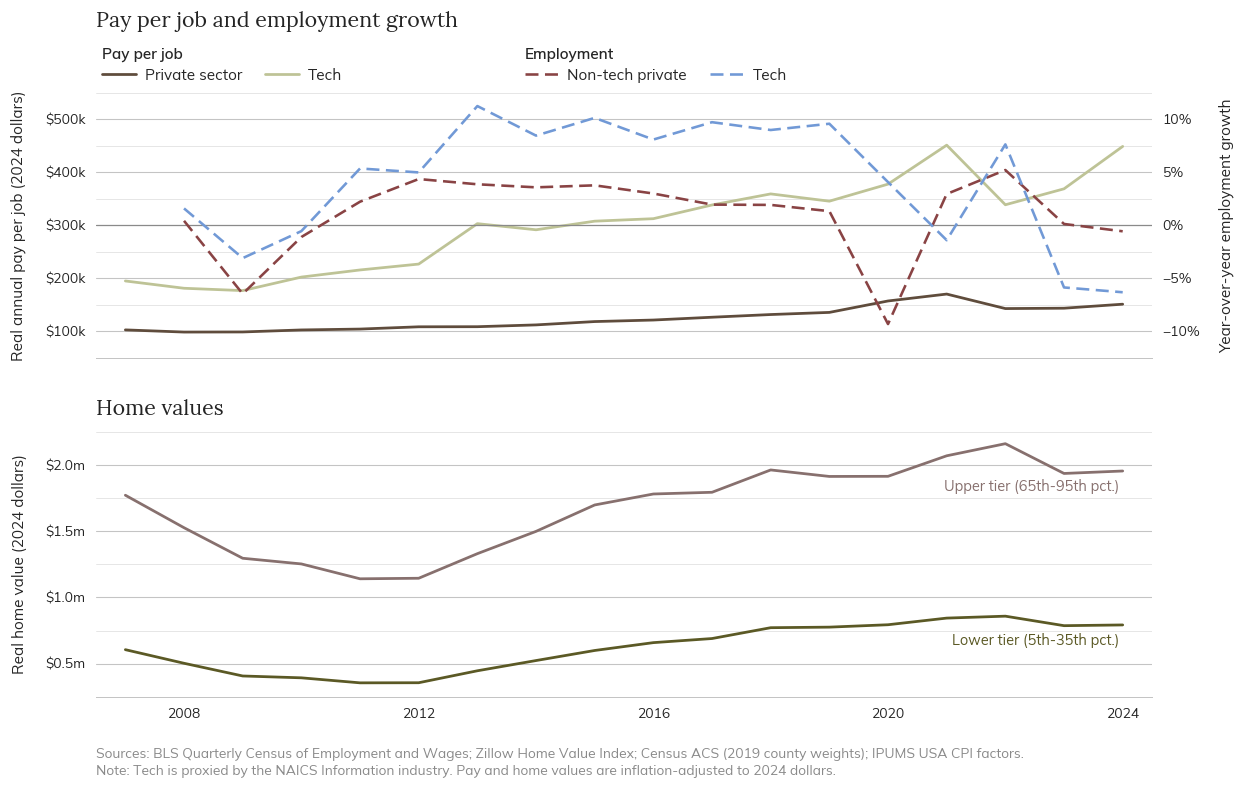

In [20]:
cycle = results["regional_cycle_annual"].sort_values("year").copy()

cycle["nontech_private_employment"] = cycle["private_employment"] - cycle["tech_employment"]
cycle["nontech_private_employment_yoy"] = cycle["nontech_private_employment"].diff() / cycle["nontech_private_employment"].shift()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, layout="none")

pay_ax = axes[0]
home_ax = axes[1]
employment_ax = pay_ax.twinx()

pay_ax.plot(cycle["year"], cycle["private_pay_per_job_2024"], color=PALETTE["Ash Brown"], lw=1.8, label="Private sector")
pay_ax.plot(cycle["year"], cycle["tech_pay_per_job_2024"], color=PALETTE["Dry Sage"], lw=1.8, label="Tech")

employment_ax.plot(cycle["year"], cycle["nontech_private_employment_yoy"], color=PALETTE["Burnt Rose"], lw=1.7, linestyle=(0, (5, 2.5)), label="Non-tech private")
employment_ax.plot(cycle["year"], cycle["tech_employment_growth"], color=PALETTE["Wisteria Blue"], lw=1.7, linestyle=(0, (5, 2.5)), label="Tech")

pay_ax.set_ylabel("Real annual pay per job (2024 dollars)", labelpad=12, fontsize=10)
employment_ax.set_ylabel("Year-over-year employment growth", labelpad=12, fontsize=10)

pay_ax.set_ylim(50_000, 550_000)
pay_ax.set_yticks(np.arange(100_000, 501_000, 100_000))
pay_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x / 1000:,.0f}k"))
pay_ax.yaxis.set_minor_locator(MultipleLocator(50_000))


employment_ax.set_ylim(-.125, .125)
employment_ax.set_yticks(np.arange(-.10, .101, .05))
employment_ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

home_ax.plot(cycle["year"], cycle["lower_home_value_2024"], color=PALETTE["Olive Leaf"], lw=1.8)
home_ax.plot(cycle["year"], cycle["upper_home_value_2024"], color=PALETTE["Taupe"], lw=1.8)

home_ax.set_ylabel("Real home value (2024 dollars)", labelpad=12, fontsize=10)
home_ax.yaxis.set_major_locator(MultipleLocator(500_000))
home_ax.yaxis.set_minor_locator(MultipleLocator(250_000))
home_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}m"))
home_ax.set_ylim(250_000, 2_250_000)
home_ax.margins(y=0.10)

for ax in axes:
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.xaxis.set_minor_locator(MultipleLocator(2))
    ax.set_axisbelow(True)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(GRAY_1)
    ax.tick_params(axis="both", which="both", length=0, pad=7)

pay_ax.grid(axis="y", which="major", color=GRAY_1, linewidth=0.7)
pay_ax.grid(axis="y", which="minor", color=GRAY_1, linewidth=0.5, alpha=0.55)
home_ax.grid(axis="y", which="major", color=GRAY_1, linewidth=0.7)
home_ax.grid(axis="y", which="minor", color=GRAY_1, linewidth=0.5, alpha=0.55)

employment_ax.grid(False)
employment_ax.spines["top"].set_visible(False)
employment_ax.spines["left"].set_visible(False)
employment_ax.spines["right"].set_visible(False)
employment_ax.tick_params(axis="y", which="both", length=0, pad=7)
employment_ax.axhline(0, color=GRAY_2, linewidth=0.8, zorder=0)

home_ax.set_xlim(cycle["year"].min() - 0.5, cycle["year"].max() + 0.5)
home_ax.set_xlabel("")

pay_ax.text(0, 1.23, "Pay per job and employment growth", transform=pay_ax.transAxes, ha="left", va="bottom", fontsize=14, fontfamily=TITLE_FONT, color=BLACK)
home_ax.text(0, 1.045, "Home values", transform=home_ax.transAxes, ha="left", va="bottom", fontsize=14, fontfamily=TITLE_FONT, color=BLACK)

pay_legend = pay_ax.legend(title="Pay per job", loc="lower left", bbox_to_anchor=(0, 1.015), frameon=False, borderaxespad=0, handlelength=2.2, handletextpad=0.6, labelspacing=0.35, columnspacing=1.5, ncol=2, alignment="left")
employment_legend = employment_ax.legend(title="Employment", loc="lower left", bbox_to_anchor=(0.40, 1.015), frameon=False, borderaxespad=0, handlelength=2.2, handletextpad=0.6, labelspacing=0.35, columnspacing=1.5, ncol=2, alignment="left")

pay_legend.get_title().set_fontweight(600)
employment_legend.get_title().set_fontweight(600)

for col, label, color, offset in [("lower_home_value_2024", "Lower tier (5th-35th pct.)", PALETTE["Olive Leaf"], -10), ("upper_home_value_2024", "Upper tier (65th-95th pct.)", PALETTE["Taupe"], -10)]:
    last = cycle.dropna(subset=[col]).iloc[-1]
    home_ax.annotate(label, (last["year"], last[col]), xytext=(-2, offset), textcoords="offset points", ha="right", va="center", color=color, fontsize=9.5)

fig.subplots_adjust(left=0.10, right=0.90, top=0.79, bottom=0.18, hspace=0.28)

add_caption(fig, source="Sources: BLS Quarterly Census of Employment and Wages; Zillow Home Value Index; Census ACS (2019 county weights); IPUMS USA CPI factors.", note="Tech is proxied by the NAICS Information industry. Pay and home values are inflation-adjusted to 2024 dollars.", x=0.10, y=0.02)

finish(fig, "pay_employment_home_values", preserve_layout=True)

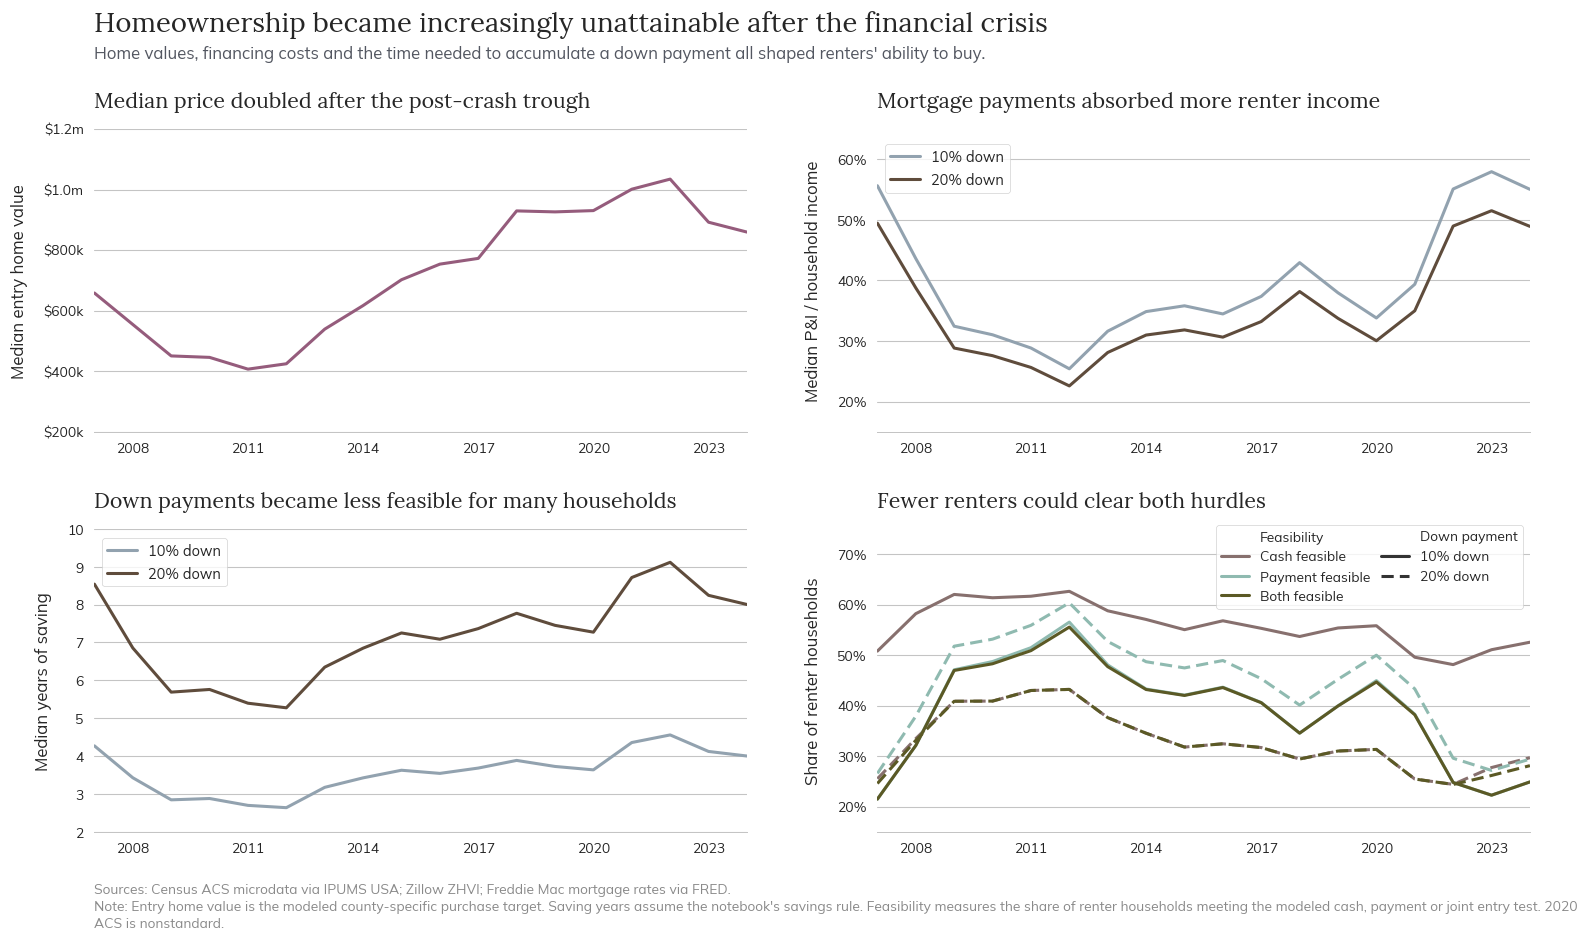

In [21]:
entry_report = results["entry_hurdle_annual"][["YEAR", "down_payment_fraction", "entry_home_value_p50_2024", "pi_income_share_p50", "years_saving_required_p50", "cash_feasible", "payment_feasible", "joint_feasible"]].copy()
entry_report["down_payment"] = entry_report["down_payment_fraction"].map({.10: "10% down", .20: "20% down"})
results["report_entry_hurdles"] = entry_report.copy()

entry_report_display = entry_report.copy()
entry_report_display["Median entry home value"] = entry_report_display["entry_home_value_p50_2024"]
entry_report_display["Median P&I / income"] = entry_report_display["pi_income_share_p50"]
entry_report_display["Median years of saving"] = entry_report_display["years_saving_required_p50"]
entry_report_display["Cash feasible"] = entry_report_display["cash_feasible"]
entry_report_display["Payment feasible"] = entry_report_display["payment_feasible"]
entry_report_display["Both feasible"] = entry_report_display["joint_feasible"]
entry_report_display = entry_report_display[["YEAR", "down_payment", "Median entry home value", "Median P&I / income", "Median years of saving", "Cash feasible", "Payment feasible", "Both feasible"]].rename(columns={"YEAR": "Year", "down_payment": "Down payment"})

entry_values = entry_report_display.drop_duplicates("Year")
feasibility_long = entry_report_display[["Year", "Down payment", "Cash feasible", "Payment feasible", "Both feasible"]].melt(id_vars=["Year", "Down payment"], var_name="Feasibility", value_name="Value")


feasibility_palette = {"Cash feasible": PALETTE["Taupe"], "Payment feasible": PALETTE["Pearl Aqua"], "Both feasible": PALETTE["Olive Leaf"]}

fig, axes = plt.subplots(2, 2, figsize=(15, 9), layout="none")

sns.lineplot(data=entry_values, x="Year", y="Median entry home value", color=PALETTE["Dusty Lavender"], lw=2, errorbar=None, ax=axes[0, 0], legend=False)
sns.lineplot(data=entry_report_display, x="Year", y="Median P&I / income", hue="Down payment", palette=DOWN_COLORS, lw=2, errorbar=None, ax=axes[0, 1])
sns.lineplot(data=entry_report_display, x="Year", y="Median years of saving", hue="Down payment", palette=DOWN_COLORS, lw=2, errorbar=None, ax=axes[1, 0])
sns.lineplot(data=feasibility_long, x="Year", y="Value", hue="Feasibility", style="Down payment", palette=feasibility_palette, style_order=["10% down", "20% down"], dashes={"10% down": "", "20% down": (4, 2)}, lw=2, errorbar=None, ax=axes[1, 1])

style_axis(axes[0, 0], "Median price doubled after the post-crash trough", "Median entry home value")
style_axis(axes[0, 1], "Mortgage payments absorbed more renter income", "Median P&I / household income")
style_axis(axes[1, 0], "Down payments became less feasible for many households", "Median years of saving")
style_axis(axes[1, 1], "Fewer renters could clear both hurdles", "Share of renter households")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.set_xlim(entry_report_display["Year"].min(), entry_report_display["Year"].max())

axes[0, 0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x / 1_000_000:.1f}m" if x >= 1_000_000 else f"${x / 1000:.0f}k"))
axes[0, 0].set_ylim(200000, 1200000)
axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[0, 1].set_ylim(.15, .65)
axes[1, 0].set_ylim(2, 10)
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[1, 1].set_ylim(.15, .75)

axes[0, 1].legend(loc="upper left", frameon=True, fontsize=9.5, title=None, handlelength=2, bbox_to_anchor=(0, 0.975), columnspacing=0.8)
axes[1, 0].legend(loc="upper left", frameon=True, fontsize=9.5, title=None, handlelength=2, bbox_to_anchor=(0, 0.995), columnspacing=0.8)
axes[1, 1].legend(loc="upper right", frameon=True, fontsize=9, title=None, ncol=2, handlelength=2, columnspacing=0.8, bbox_to_anchor=(1, 1.035))

fig.subplots_adjust(left=.075, right=.945, top=.84, bottom=.13, hspace=.32, wspace=.2)

fig.suptitle("Homeownership became increasingly unattainable after the financial crisis", x=.075, y=.96, ha="left", fontfamily=TITLE_FONT, fontsize=18)
fig.text(.075, .925, "Home values, financing costs and the time needed to accumulate a down payment all shaped renters' ability to buy.", ha="left", va="top", fontsize=11, color="#535761", fontfamily=BODY_FONT)

add_caption(fig, source="Sources: Census ACS microdata via IPUMS USA; Zillow ZHVI; Freddie Mac mortgage rates via FRED.", note="Entry home value is the modeled county-specific purchase target. Saving years assume the notebook's savings rule. Feasibility measures the share of renter households meeting the modeled cash, payment or joint entry test. 2020 ACS is nonstandard.", x=.075, y=.025)

finish(fig, "entry_hurdles_overview", preserve_layout=True)

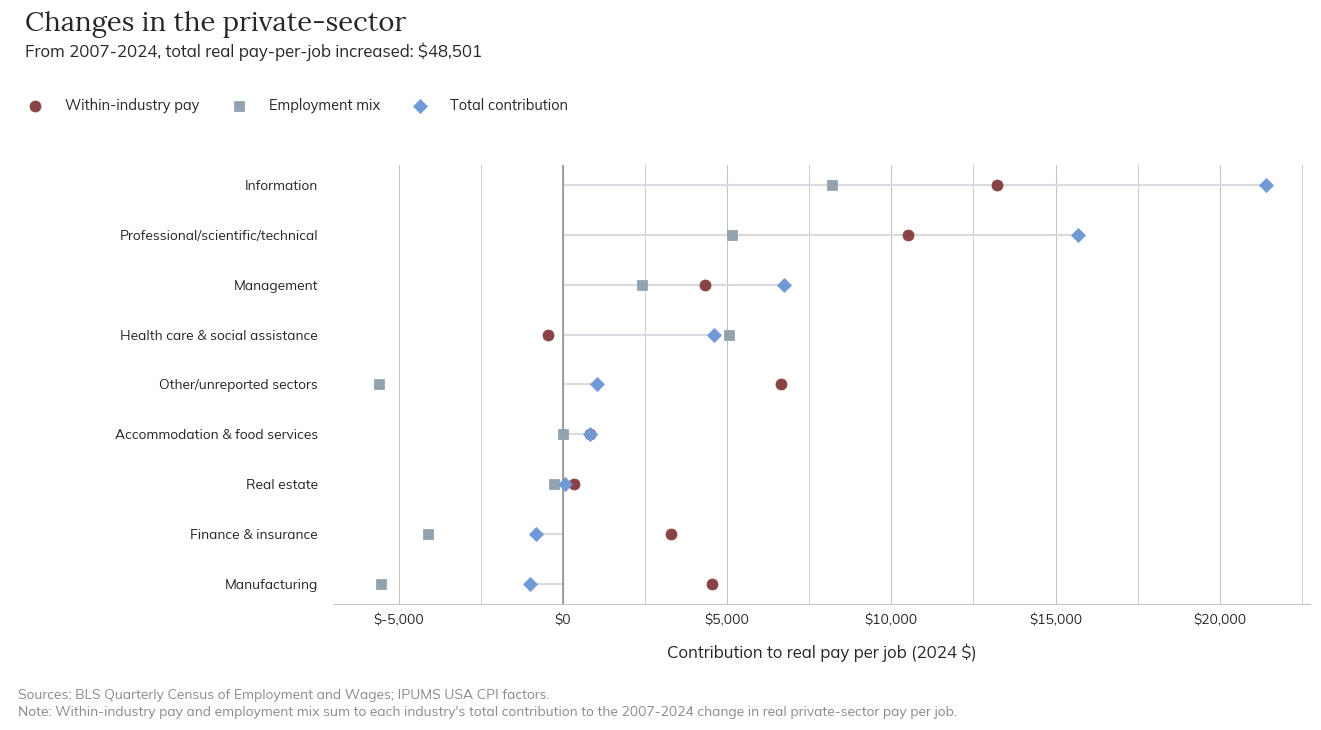

In [22]:
industry = results["industry_pay_change_contributions"].copy()
end_year = int(industry.year.max())

d = (industry.loc[industry.year.eq(end_year)] .copy() .sort_values("total_contribution"))
d["Industry"] = d.sector.map(SECTOR_NAMES).fillna(d.sector)

pay_change = (cycle.set_index("year").loc[end_year, "private_pay_per_job_2024"] - cycle.set_index("year").loc[2007, "private_pay_per_job_2024"]
)

fig, ax = plt.subplots(figsize=(12.5, 7), layout="none")
y = np.arange(len(d))

for i, row in enumerate(d.itertuples()):
    ax.plot([0, row.total_contribution], [i, i], color="#d9dcdf", lw=1.4, zorder=1)

ax.scatter(d.wage_effect, y, label="Within-industry pay", color=PALETTE["Burnt Rose"], s=52, zorder=3)

ax.scatter(d.employment_mix_effect, y, label="Employment mix", color=PALETTE["Cool Steel"], marker="s", s=46, zorder=3)

ax.scatter(d.total_contribution, y, label="Total contribution", color=PALETTE["Wisteria Blue"], marker="D", s=42, zorder=4)

ax.set_yticks(y, d.Industry)
ax.axvline(0, color="#858b92", lw=1.0)
ax.set_xlabel("Contribution to real pay per job (2024 $)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v:,.0f}"))

style_axis(ax, horizontal=True, minor=True, y_ticks=True)

fig.subplots_adjust(left=.26, right=.97, bottom=.19, top=.76)

fig.suptitle("Changes in the private-sector", x=.035, y=.96, ha="left", fontfamily=TITLE_FONT, fontsize=18)

fig.text(.035, .90, f"From 2007-2024, total real pay-per-job increased: ${pay_change:,.0f}", fontsize=11)

shared_legend(fig, [ax], ncol=3, x=.025, y=.855, fontsize=9.5)

add_caption(fig, source="Sources: BLS Quarterly Census of Employment and Wages; IPUMS USA CPI factors.", note="Within-industry pay and employment mix sum to each industry's total contribution to the 2007-2024 change in real private-sector pay per job.", x=.03, y=.025)

finish(fig, "industry_pay_decomposition", preserve_layout=True)

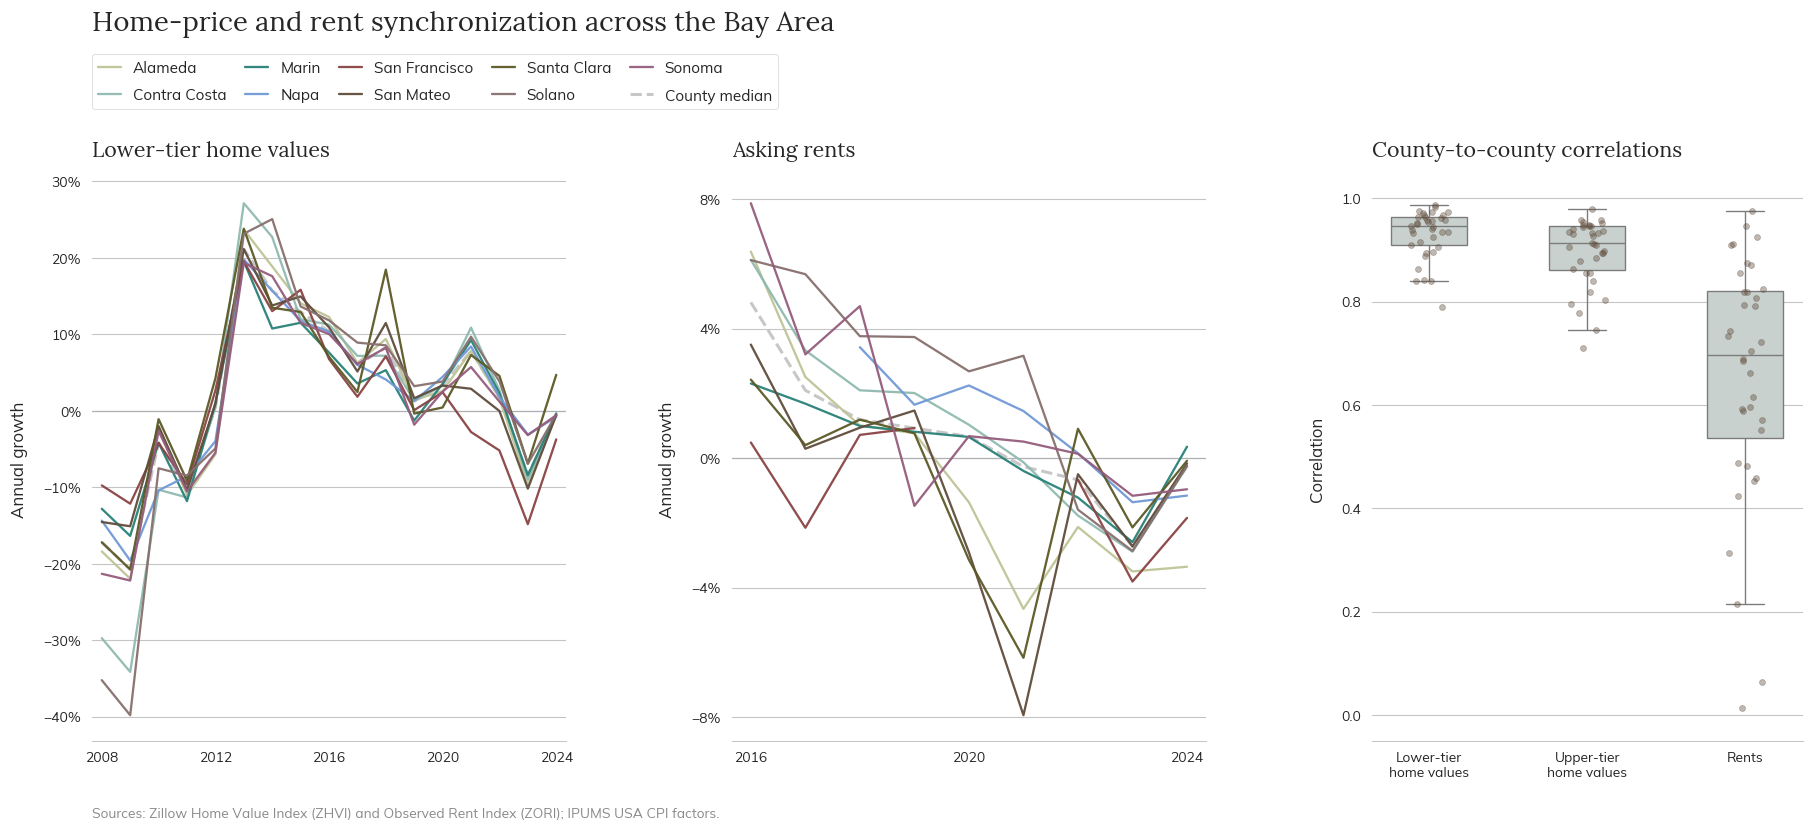

In [23]:
county = results["county_housing_pressure_panel"].copy().sort_values(["county_fips", "year"])
county["county_fips"] = pd.to_numeric(county.county_fips, errors="raise").astype("Int64").astype("string").str.zfill(5)
county_names = {str(code).zfill(5): name for code, name in COUNTY_NAMES.items()}
county["County"] = county.county_fips.map(county_names)
assert county.County.notna().all() and set(county.county_fips) == set(county_names)
assert not county.duplicated(["county_fips", "year"]).any()
county_order = list(county_names.values())
county_colors = [p for k, p in PALETTE.items() if k != "Cool Steel"]

sync = results["county_growth_synchronization"].copy()
fig, axes = plt.subplots(1, 3, figsize=(17, 8), gridspec_kw={"width_ratios": [1.1, 1.1, 1]})
county_handles = []
for i, (ax, measure, title) in enumerate(zip(axes[:2], ["lower_growth", "rent_growth"], ["Lower-tier home values", "Asking rents"])):
    wide = county.pivot(index="year", columns="County", values=measure).reindex(columns=county_order)
    available = wide.dropna(how="all")
    median_line, = ax.plot(wide.index, wide.median(axis=1), color="#b5b5b5", lw=2, alpha=.75, zorder=2, label="County median", linestyle="--")
    for name, color in zip(county_order, county_colors):
        line, = ax.plot(wide.index, wide[name], color=color, lw=1.5, alpha=.95, zorder=3, label=name)
        if i == 0:
            county_handles.append(line)
    style_axis(ax, title, "Annual growth")
    ax.axhline(0, color="#adb0b5", lw=.8, zorder=1)
    ax.yaxis.set_major_locator(MultipleLocator(.10 if i == 0 else .04))
    ax.yaxis.set_minor_locator(MultipleLocator(.05 if i == 0 else .02))
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    start, end = int(available.index.min()), int(available.index.max())
    ax.set_xlim(start - .35, end + .35)
    ax.set_xticks(sorted(set([start, *range(((start + 3) // 4) * 4, end + 1, 4), end])))
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=0)
order = ["lower_growth", "upper_growth", "rent_growth"]
sns.boxplot(data=sync, x="measure", y="correlation", order=order, color="#c6d3ce", width=.48, linewidth=.9, showfliers=False, ax=axes[2])
for position, measure in enumerate(order):
    values = sync.loc[sync.measure.eq(measure), "correlation"].dropna().sort_values().to_numpy()
    offsets = np.random.default_rng(17 + position).uniform(-.12, .12, len(values))
    axes[2].scatter(position + offsets, values, color=PALETTE["Ash Brown"], s=15, alpha=.4, zorder=3)
axes[2].set_xticks(range(3), ["Lower-tier\nhome values", "Upper-tier\nhome values", "Rents"])
correlation_min = sync.correlation.min()
axes[2].set(xlabel="", ylim=(min(-.05, correlation_min - .05), 1.04))
axes[2].yaxis.set_major_locator(MultipleLocator(.2))
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:.1f}"))
style_axis(axes[2], "County-to-county correlations", "Correlation")
fig.subplots_adjust(left=.065, right=.98, top=.76, bottom=.12, wspace=.36)
fig.suptitle("Home-price and rent synchronization across the Bay Area", x=.065, y=.95, ha="left", fontfamily=TITLE_FONT, fontsize=18)
fig.legend(handles=county_handles + [median_line], labels=county_order + ["County median"], loc="upper left", bbox_to_anchor=(.065, .90), ncol=5, frameon=True, borderaxespad=0, handlelength=1.5, columnspacing=1.2, labelspacing=.8)

add_caption(fig, source="Sources: Zillow Home Value Index (ZHVI) and Observed Rent Index (ZORI); IPUMS USA CPI factors.", note=None, x=.065, y=.025)
finish(fig, "spatial_synchronization", preserve_layout=True)

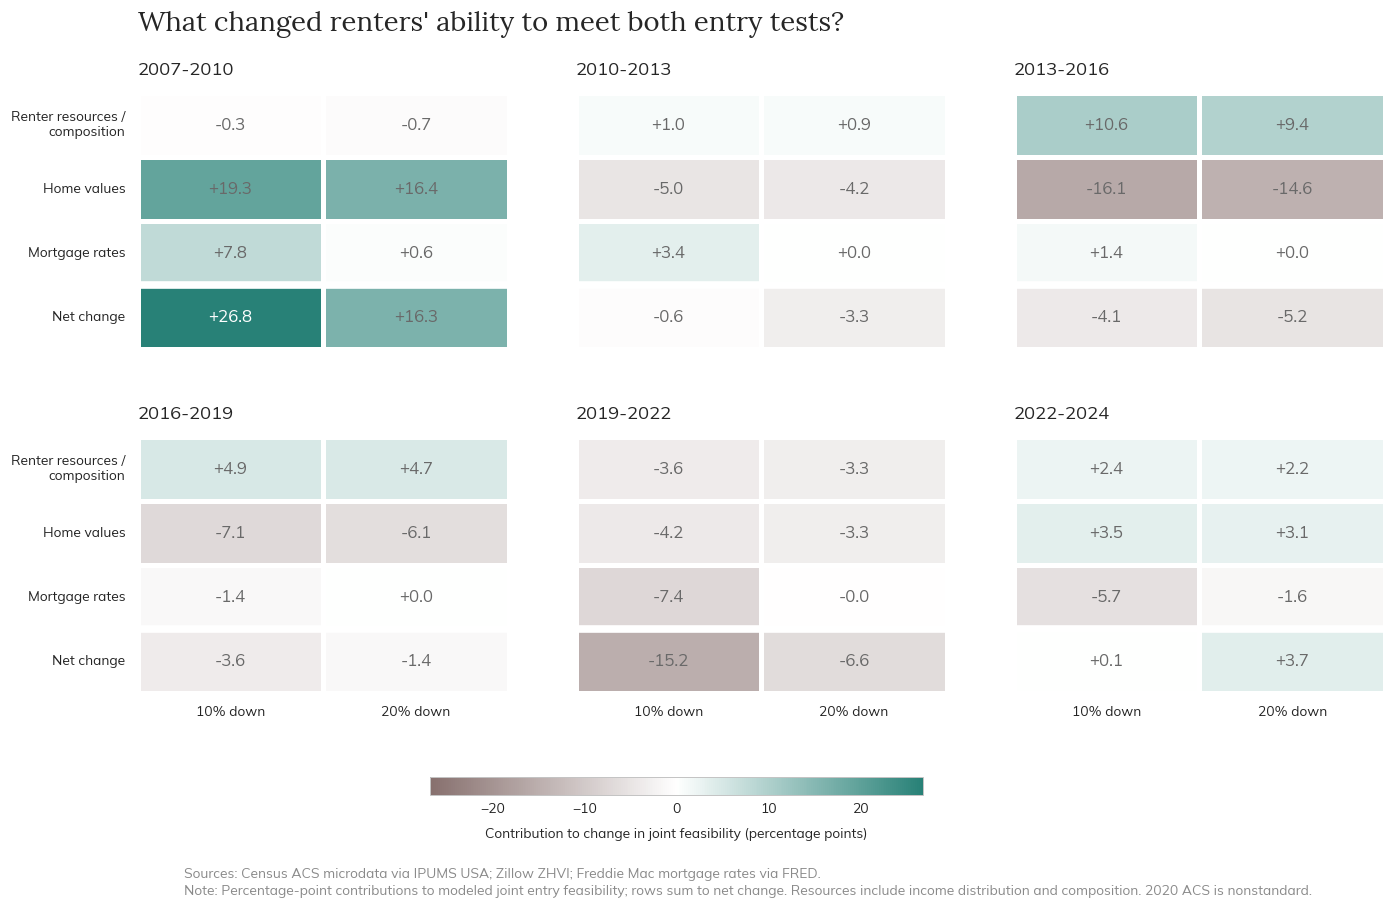

In [24]:
shapley = results["entry_feasibility_shapley"].copy()
entry_periods = [(2007, 2010), (2010, 2013), (2013, 2016), (2016, 2019), (2019, 2022), (2022, 2024)]

factor_names = {"resources": "Renter resources /\ncomposition", "home_values": "Home values", "mortgage_rates": "Mortgage rates"}

matrices = []

for start, end in entry_periods:
    columns = []

    for down in DOWN_NAMES:
        g = shapley.loc[shapley.start.eq(start) & shapley.end.eq(end) & shapley.down_payment_fraction.eq(down)]

        effects = (g.set_index("factor") .shapley_effect .reindex(factor_names) * 100)

        net = g.total_change.iloc[0] * 100

        columns.append(pd.Series(list(effects) + [net], index=list(factor_names.values()) + ["Net change"], name=f"{down:.0%} down"))

    matrices.append(pd.concat(columns, axis=1))

limit = max(float(abs(matrix).max().max()) for matrix in matrices)

fig, axes = plt.subplots(2, 3, figsize=(14, 8.8), sharex=True, sharey=True, layout="none")

for j, (ax, matrix, (start, end)) in enumerate(zip(axes.flat, matrices, entry_periods)):
    sns.heatmap(matrix, annot=True, fmt="+.1f", cmap=DIVERGING, vmin=-limit, vmax=limit, center=0, linewidths=2, linecolor="white", cbar=False,
        annot_kws={"fontsize": 11}, ax=ax)

    ax.set_title(f"{start}-{end}", fontfamily=BODY_FONT, fontsize=12, pad=12)

    ax.tick_params(axis="both", length=0, pad=8, rotation=0)
    ax.tick_params(axis="y", labelleft=(j % 3 == 0))
    ax.set(xlabel="", ylabel="")
    ax.hlines(3, 0, 2, colors="white", lw=5)

    for text, value in zip(ax.texts, matrix.to_numpy().ravel()):
        rgb = np.asarray(DIVERGING((value + limit) / (2 * limit))[:3])
        lum = (np.where(rgb <= .04045, rgb / 12.92, ((rgb + .055) / 1.055) ** 2.4) @ [.2126, .7152, .0722])

        text.set_color("dimgrey" if lum > .25 else "white")

fig.subplots_adjust(left=.15, right=.96, top=.83, bottom=.21, hspace=.34, wspace=.18)

cax = fig.add_axes([.34, .105, .32, .018])

cbar = fig.colorbar(axes.flat[0].collections[0], cax=cax, orientation="horizontal")
cbar.set_label("Contribution to change in joint feasibility (percentage points)", labelpad=8, fontsize=9)
cbar.ax.tick_params(length=0, pad=5)

fig.suptitle("What changed renters' ability to meet both entry tests?", x=.15, y=.915, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Sources: Census ACS microdata via IPUMS USA; Zillow ZHVI; Freddie Mac mortgage rates via FRED.", note="Percentage-point contributions to modeled joint entry feasibility; rows sum to net change. Resources include income distribution and composition. 2020 ACS is nonstandard.", x=.18, y=.018)

finish(fig, "entry_change_accounting", preserve_layout=True)

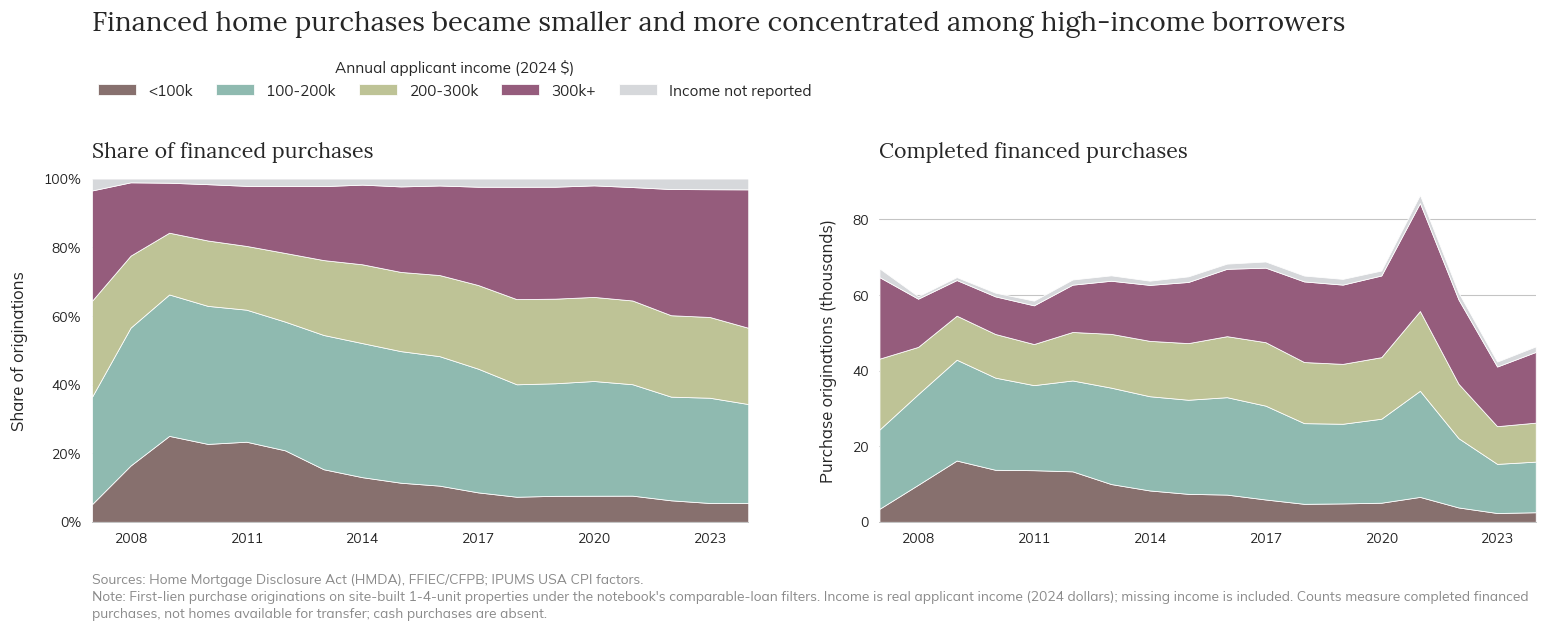

In [25]:
borrowers = results["purchase_borrower_income_composition"].copy()
borrowers["Income band"] = (borrowers.income_band .astype("string") .fillna("Income not reported"))

order = BORROWER_ORDER + ["Income not reported"]
borrower_colors = [PALETTE["Taupe"], PALETTE["Pearl Aqua"], PALETTE["Dry Sage"], PALETTE["Dusty Lavender"], "#d6d8db"]

share_p = (borrowers.pivot(index="year", columns="Income band", values="share") .reindex(columns=order) .fillna(0))

count_p = (borrowers.pivot(index="year", columns="Income band", values="originations") .reindex(columns=order) .fillna(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout="none")

axes[0].stackplot(share_p.index, *[share_p[col] for col in order], labels=order, colors=borrower_colors, edgecolor="white", linewidth=.5)

axes[1].stackplot(count_p.index, *[count_p[col] / 1000 for col in order], labels=order, colors=borrower_colors, edgecolor="white", linewidth=.5)

style_axis(axes[0], "Share of financed purchases", "Share of originations")
style_axis(axes[1], "Completed financed purchases", "Purchase originations (thousands)")

axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[1].set_ylim(bottom=0)

for ax in axes:
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.set_xlim(borrowers.year.min(), borrowers.year.max())

fig.subplots_adjust(left=.075, right=.95, top=.71, bottom=.19, wspace=.2)

fig.suptitle("Financed home purchases became smaller and more concentrated among high-income borrowers", x=.075, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

shared_legend(fig, axes, ncol=5, y=.9, x=.075, title="Annual applicant income (2024 $)")

add_caption(fig, source="Sources: Home Mortgage Disclosure Act (HMDA), FFIEC/CFPB; IPUMS USA CPI factors.", note="First-lien purchase originations on site-built 1-4-unit properties under the notebook's comparable-loan filters. Income is real applicant income (2024 dollars); missing income is included. Counts measure completed financed purchases, not homes available for transfer; cash purchases are absent.", x=.075, y=.022)

finish(fig, "borrower_income_composition", preserve_layout=True)

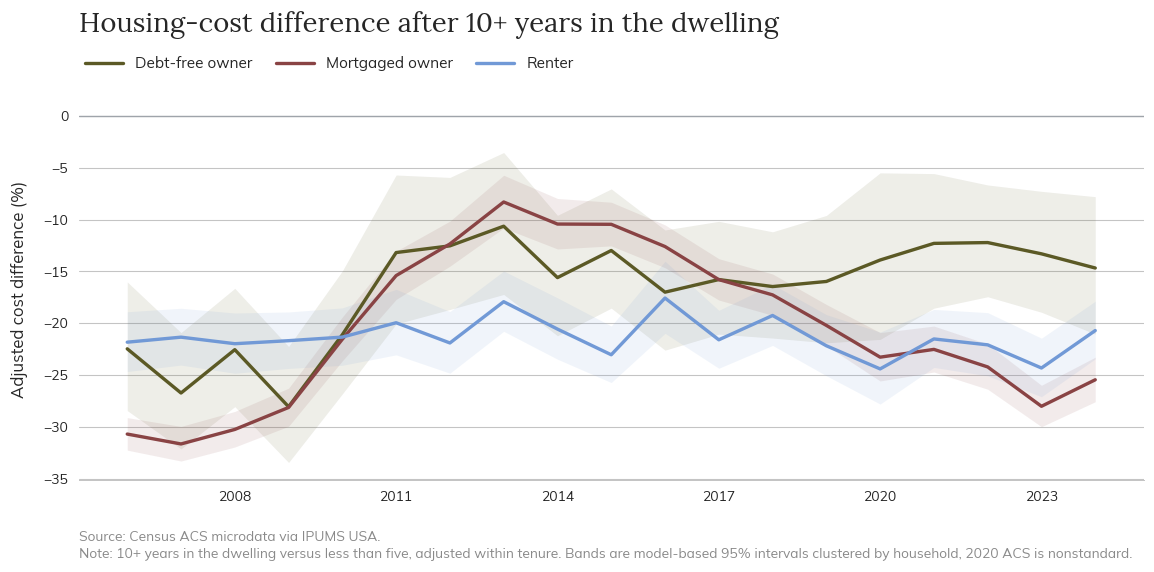

In [26]:
cost = results["adjusted_incumbency_cost_gap"].copy().sort_values(["tenure", "YEAR"])

fig, ax = plt.subplots(figsize=(11, 5.5), layout="none")

for tenure, g in cost.groupby("tenure"):
    label = TENURE_NAMES[tenure]
    color = TENURE_COLORS[label]

    ax.plot(g.YEAR, 100 * g.adjusted_percent_cost_gap, label=label, color=color, lw=2.2)

    ax.fill_between(g.YEAR, 100 * g.ci_low_percent, 100 * g.ci_high_percent, alpha=.10, color=color, linewidth=0)

ax.axhline(0, color="#9fa4aa", lw=.9)

style_axis(ax, "", "Adjusted cost difference (%)")

ax.set_xlabel("")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

fig.subplots_adjust(left=.10, right=.98, top=.82, bottom=.19)

fig.suptitle("Housing-cost difference after 10+ years in the dwelling", x=.10, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

shared_legend(fig, [ax], ncol=3, y=.9, x=.10)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA.", note="10+ years in the dwelling versus less than five, adjusted within tenure. Bands are model-based 95% intervals clustered by household, 2020 ACS is nonstandard.", x=.10, y=.025)

finish(fig, "adjusted_residence_cost_gap", preserve_layout=True)

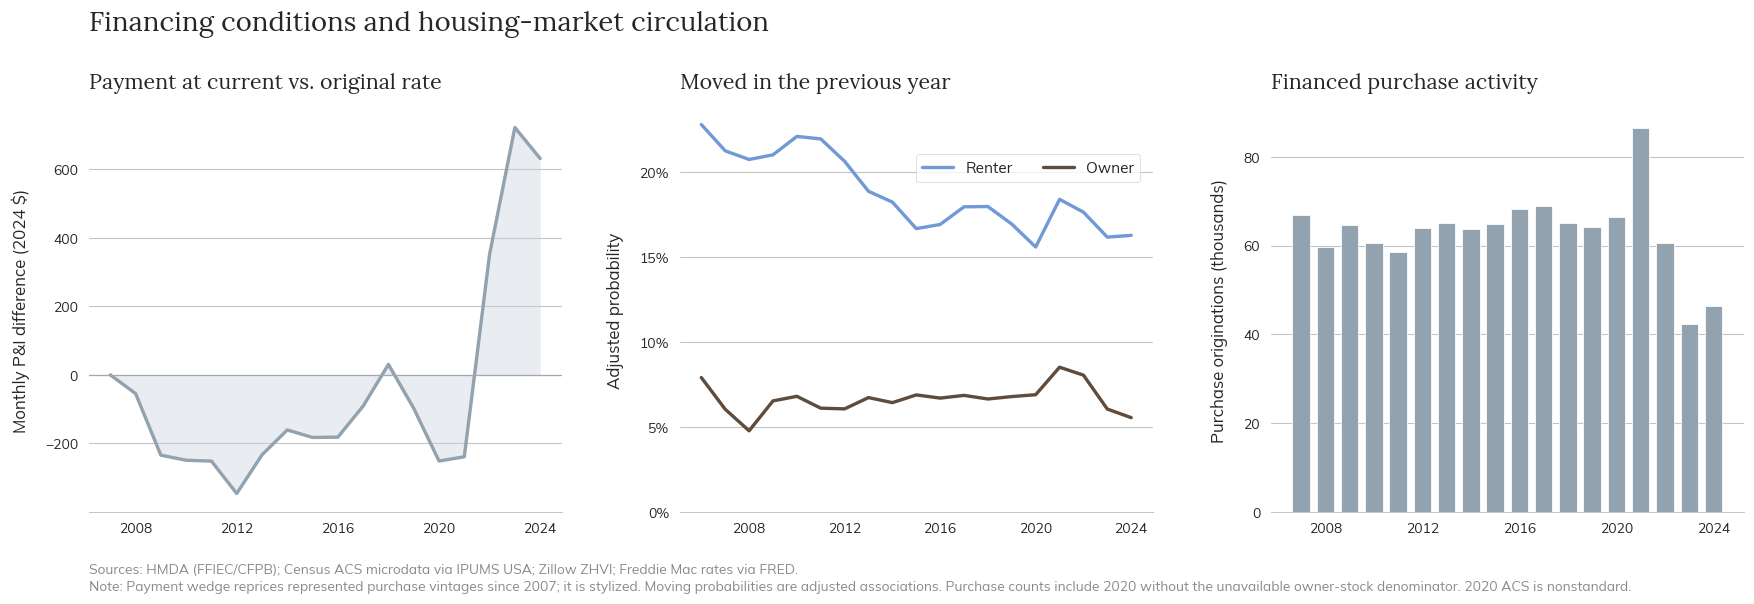

In [27]:
lockin = results["mortgage_lockin_annual"].copy().sort_values("year")
mobility = results["adjusted_mobility_gap_annual"].copy().sort_values("YEAR")
circulation = results["mortgage_market_annual"].copy().sort_values("year")

fig, axes = plt.subplots(1, 3, figsize=(17, 6), layout="none")

axes[0].fill_between(lockin.year, 0, lockin.mortgage_lockin_payment_wedge_2024, color="#c8d1da", alpha=.40, linewidth=0)

axes[0].plot(lockin.year, lockin.mortgage_lockin_payment_wedge_2024, color=PALETTE["Cool Steel"], lw=2.2)

axes[0].axhline(0, color="#a5a9af", lw=.8)

axes[1].plot(mobility.YEAR, mobility.adjusted_renter_recent_move_probability, color=TENURE_COLORS["Renter"], label="Renter", lw=2.2)

axes[1].plot(mobility.YEAR, mobility.adjusted_owner_recent_move_probability, color=TENURE_COLORS["Owner"], label="Owner", lw=2.2)

axes[1].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

axes[2].bar(circulation.year, circulation.purchase_originations / 1000, color=PALETTE["Cool Steel"], width=.72)

for ax, title, ylabel in zip(axes, ["Payment at current vs. original rate", "Moved in the previous year", "Financed purchase activity"], ["Monthly P&I difference (2024 $)", "Adjusted probability", "Purchase originations (thousands)"]):
    style_axis(ax, title, ylabel)
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

axes[1].set_ylim(bottom=0)
axes[2].set_ylim(bottom=0)

axes[1].legend(loc="lower left", bbox_to_anchor=(0.5, 0.82), ncol=2, borderaxespad=0, frameon=True)

fig.subplots_adjust(left=.065, right=.95, top=.8, bottom=.19, wspace=.25)

fig.suptitle("Financing conditions and housing-market circulation", x=.065, y=.95, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Sources: HMDA (FFIEC/CFPB); Census ACS microdata via IPUMS USA; Zillow ZHVI; Freddie Mac rates via FRED.", note="Payment wedge reprices represented purchase vintages since 2007; it is stylized. Moving probabilities are adjusted associations. Purchase counts include 2020 without the unavailable owner-stock denominator. 2020 ACS is nonstandard.", x=.065, y=.022)

finish(fig, "financing_and_circulation", preserve_layout=True)

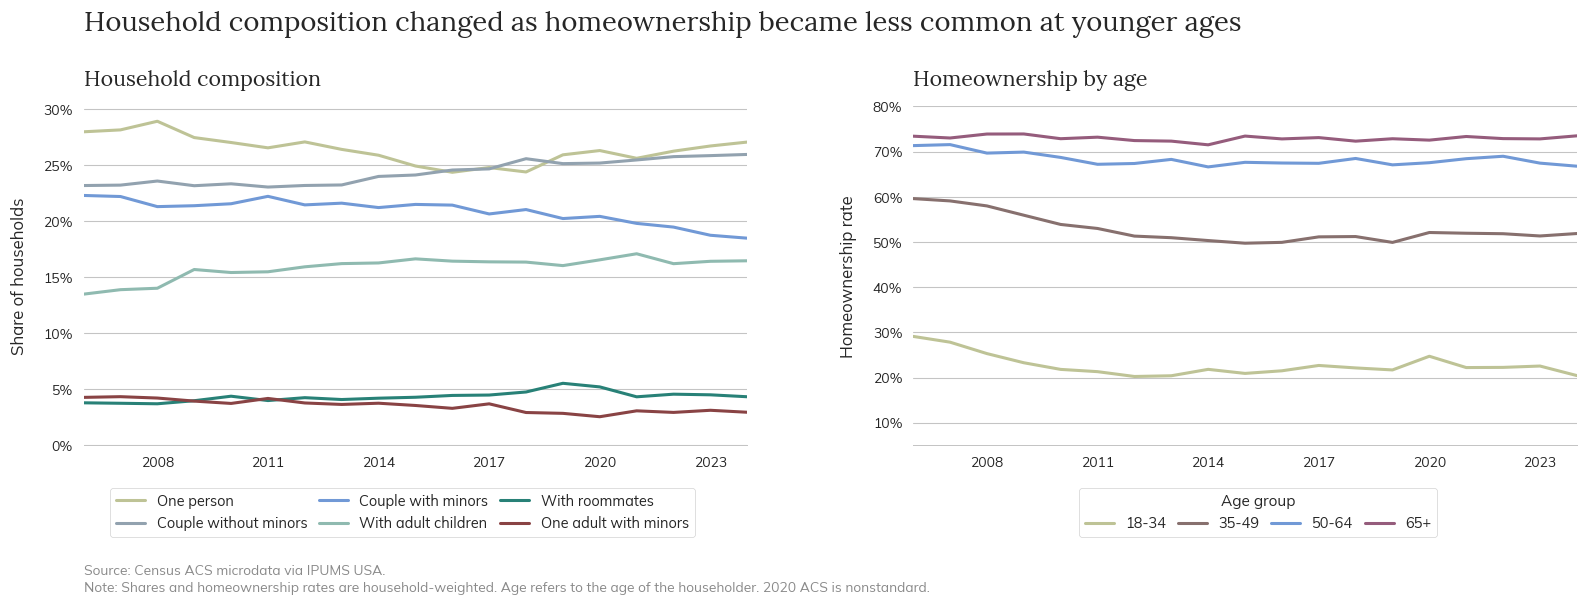

In [28]:
household_type = results["household_type_composition_annual"].copy()
household_type = household_type.loc[~household_type["household_type_total"].eq("other_household")].sort_values(["YEAR", "household_type_total"])

age_ownership = house.loc[house["age_group"].notna() & house["owner"].notna() & house["household_weight"].gt(0), ["YEAR", "age_group", "owner", "household_weight"]].copy()
age_ownership["weighted_owner"] = age_ownership["owner"].astype(float) * age_ownership["household_weight"]
age_ownership = age_ownership.groupby(["YEAR", "age_group"], observed=True, as_index=False).agg(owner_households=("weighted_owner", "sum"), households=("household_weight", "sum"))
age_ownership["homeownership_rate"] = age_ownership["owner_households"] / age_ownership["households"]
results["homeownership_rate_by_age_annual"] = age_ownership.copy()

household_type["Household type"] = household_type["household_type_total"].astype(str).str.replace("_", " ", regex=False).str.capitalize()
age_ownership["Age group"] = age_ownership["age_group"].astype(str)

household_order = household_type.groupby("Household type")["household_share"].mean().sort_values(ascending=False).index.tolist()
age_order = ["18-34", "35-49", "50-64", "65+"]

fig, axes = plt.subplots(1, 2, figsize=(15, 7), layout="none")

sns.lineplot(data=household_type, x="YEAR", y="household_share", hue="Household type", hue_order=household_order, palette=[CHART_COLORS[i] for i in [1, 0, 4, 2, 3, 5]], lw=2.0, errorbar=None, ax=axes[0])
sns.lineplot(data=age_ownership, x="YEAR", y="homeownership_rate", hue="Age group", hue_order=age_order, palette=[PALETTE[k] for k in ["Dry Sage", "Taupe", "Wisteria Blue", "Dusty Lavender"]], lw=2.0, errorbar=None, ax=axes[1])

style_axis(axes[0], "Household composition", "Share of households")
style_axis(axes[1], "Homeownership by age", "Homeownership rate")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.set_xlim(min(household_type["YEAR"].min(), age_ownership["YEAR"].min()), max(household_type["YEAR"].max(), age_ownership["YEAR"].max()))

axes[1].set_ylim(0.05, .8)

axes[0].legend(loc="upper left", bbox_to_anchor=(0.04, -.125), ncol=3, fontsize=9.5, borderaxespad=0, frameon=True, handlelength=2, columnspacing=0.8)
axes[1].legend(loc="upper left", bbox_to_anchor=(.25, -.125), ncol=4, fontsize=9.5, borderaxespad=0, frameon=True, handlelength=2, columnspacing=0.8, title="Age group")

fig.subplots_adjust(left=.075, right=.98, top=.84, bottom=.4, wspace=.25, hspace=.4)

fig.suptitle("Household composition changed as homeownership became less common at younger ages", x=.075, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA.", note="Shares and homeownership rates are household-weighted. Age refers to the age of the householder. 2020 ACS is nonstandard.", x=.075, y=.022)

finish(fig, "household_and_owner_composition", preserve_layout=True)

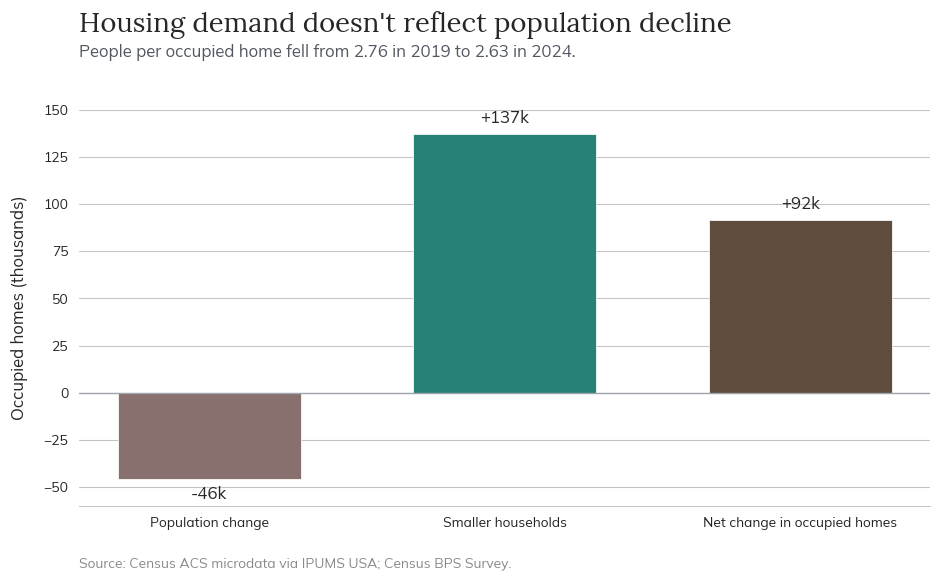

In [29]:
demand = results["occupied_home_demand_decomposition"].loc[results["occupied_home_demand_decomposition"]["start"].eq(2019) & results["occupied_home_demand_decomposition"]["end"].eq(2024)].iloc[0]

demand_plot = pd.DataFrame({"Component": ["Population change", "Smaller households", "Net change in occupied homes"], "Homes": [demand["population_component"] / 1000, demand["people_per_home_component"] / 1000, demand["occupied_home_change"] / 1000]})

fig, ax = plt.subplots(figsize=(9, 6), layout="none")

bars = ax.bar(demand_plot["Component"], demand_plot["Homes"], color=[PALETTE["Taupe"], PALETTE["Deep Ocean"], PALETTE["Ash Brown"]], width=.62)

ax.axhline(0, color="#9fa4aa", lw=.9)

for bar, value in zip(bars, demand_plot["Homes"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + (4 if value >= 0 else -4), f"{value:+,.0f}k", ha="center", va="bottom" if value >= 0 else "top", fontsize=11)

style_axis(ax, "", "Occupied homes (thousands)")
ax.set_xlabel("")
ax.set_ylim(-60, 150)

fig.subplots_adjust(left=.12, right=.98, top=.8, bottom=.20)

fig.suptitle("Housing demand doesn't reflect population decline", x=.12, y=.95, ha="left", fontfamily=TITLE_FONT, fontsize=18)
fig.text(.12, .9, f"People per occupied home fell from {demand['start_people_per_home']:.2f} in 2019 to {demand['end_people_per_home']:.2f} in 2024.", ha="left", va="top", fontsize=11, color="#535761", fontfamily=BODY_FONT)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA; Census BPS Survey.", x=.12, y=.025)

finish(fig, "occupied_home_demand_decomposition", preserve_layout=True)

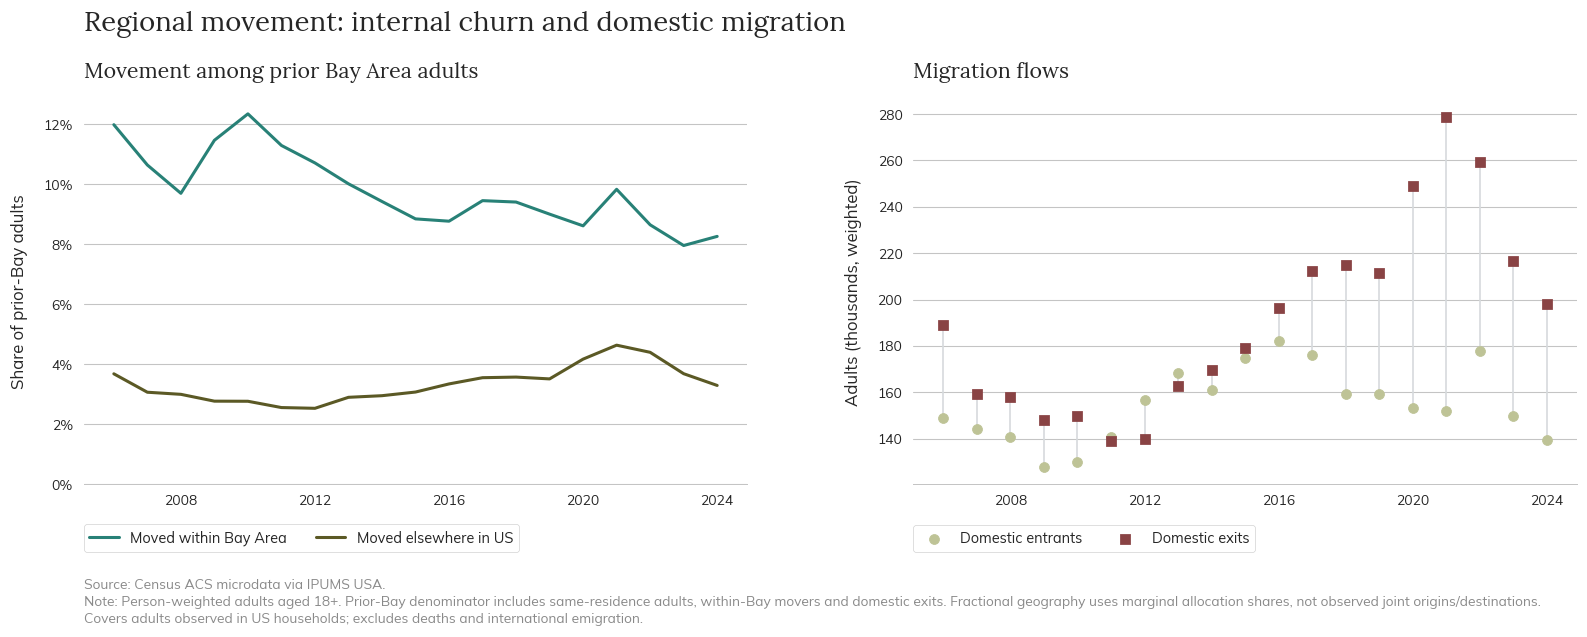

In [30]:
continuity = results["regional_continuity_annual"].copy().sort_values("year")

fig, axes = plt.subplots(1, 2, figsize=(15, 7), layout="none")

axes[0].plot(continuity.year, continuity.within_Bay_churn_share, color=PALETTE["Deep Ocean"], label="Moved within Bay Area", lw=2)
axes[0].plot(continuity.year, continuity.domestic_exit_share, color=PALETTE["Olive Leaf"], label="Moved elsewhere in US", lw=2)

axes[0].set_ylim(bottom=0)
axes[0].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))

axes[1].vlines(continuity.year, continuity.domestic_entrant_persons / 1000, continuity.domestic_exit_persons / 1000, color="#d7dadd", lw=1.1,zorder=1)
axes[1].scatter(continuity.year, continuity.domestic_entrant_persons / 1000, label="Domestic entrants", color=PALETTE["Dry Sage"], s=42, zorder=3)
axes[1].scatter(continuity.year, continuity.domestic_exit_persons / 1000, label="Domestic exits", color=PALETTE["Burnt Rose"], s=38, marker="s",zorder=3)

style_axis(axes[0], "Movement among prior Bay Area adults", "Share of prior-Bay adults")
style_axis(axes[1], "Migration flows", "Adults (thousands, weighted)")

for ax in axes:
    ax.set_xlabel("")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

axes[0].legend(loc="lower left", bbox_to_anchor=(0, -.175), ncol=2, fontsize=9.5, borderaxespad=0, frameon=True)
axes[1].legend(loc="lower left", bbox_to_anchor=(0, -.175), ncol=2, fontsize=9.5, borderaxespad=0, frameon=True)

fig.subplots_adjust(left=.075, right=.98, top=.85, bottom=.35, wspace=.25, hspace=.3)

fig.suptitle("Regional movement: internal churn and domestic migration", x=.075, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

add_caption(fig, source="Source: Census ACS microdata via IPUMS USA.", note="Person-weighted adults aged 18+. Prior-Bay denominator includes same-residence adults, within-Bay movers and domestic exits. Fractional geography uses marginal allocation shares, not observed joint origins/destinations. Covers adults observed in US households; excludes deaths and international emigration.", x=.075, y=.022)

finish(fig, "regional_movement", preserve_layout=True)

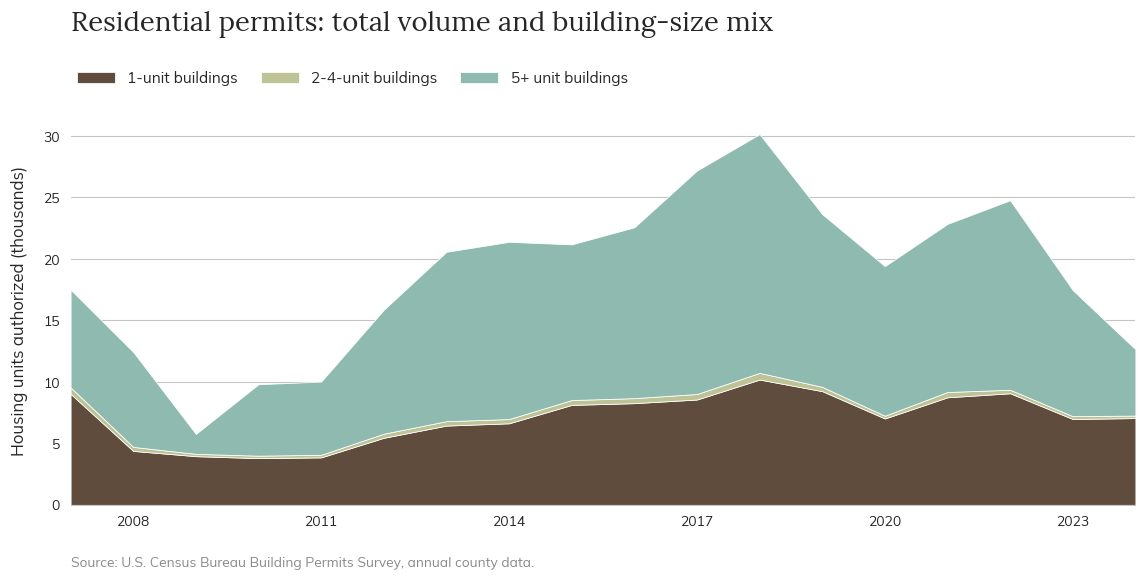

In [31]:
supply = results["housing_demand_supply_annual"].copy().sort_values("year")

supply["two_four_unit_units"] = (supply.two_unit_units + supply.three_four_unit_units)

permit_columns = {"one_unit_units": "1-unit buildings", "two_four_unit_units": "2-4-unit buildings", "five_plus_unit_units": "5+ unit buildings"
}
p = (supply.set_index("year") [list(permit_columns)] .sort_index())

fig, ax = plt.subplots(figsize=(11, 5.8), layout="none")

ax.stackplot(p.index, *[p[col] / 1000 for col in permit_columns], labels=list(permit_columns.values()), colors=[PALETTE["Ash Brown"], PALETTE["Dry Sage"], PALETTE["Pearl Aqua"]], edgecolor="white", linewidth=.5)


style_axis(ax, "", "Housing units authorized (thousands)")

ax.set_xlabel("")
ax.set_ylim(bottom=0)
ax.set_xlim(p.index.min(), p.index.max())
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=7))

fig.subplots_adjust(left=.10, right=.98, top=.80, bottom=.19)

fig.suptitle("Residential permits: total volume and building-size mix", x=.10, y=.965, ha="left", fontfamily=TITLE_FONT, fontsize=18)

shared_legend(fig, [ax], ncol=4, y=.88, x=.10)

add_caption(fig, source='Source: U.S. Census Bureau Building Permits Survey, annual county data.', x=.10, y=.025)

finish(fig, "permits_by_building_size", preserve_layout=True)